In [2]:
import os
import time
import random
import warnings
from datetime import date
import gc

import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
from lxml import etree # type: ignore <- pylance milně hlásí chybu
from pathlib import Path
import time
import sys
import polars as pl
import polars.selectors as cs
import json
import pickle
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patheffects as path_effects
from ydata_profiling import ProfileReport
import geopandas as gpd
import ipywidgets as widgets
from dateutil.relativedelta import relativedelta


current_dir = Path(__file__).resolve().parent if "__file__" in locals() else Path.cwd()
sys.path.append(str(current_dir.parent))
from utils import *
from schemas import *
from clean import *
from visualisation_utils import *

pl.Config.set_tbl_cols(-1)
os.chdir(r'E:\CVUT_BAP')
# os.chdir(r'C:\Users\adamp\Projects\CVUT_BAP')
SEED=42
PRINT = True
DATA_PATH = r"kod\data\processed\mereni.parquet"
TEMP_PATH = r"kod\data\processed\mereni.tmp.parquet"

# Načtení dat

In [2]:
df = pl.read_parquet(r'kod\data\extracted\data_z_mericich_pristroju\parquet', schema=mereni_schema)
if PRINT: describe(df, True)

CisloProtokolu,DatumProhlidky,StaniceCislo,Zahajeni,Ukonceni,OdpovednaOsoba,Prohlidka_CisloProtokolu,Prohlidka_DatumProhlidky,MericiPristroj_Vyrobce,MericiPristroj_Typ,MericiPristroj_Verze,MericiPristroj_OBD,MericiPristroj_VerzeSoftware,Poznamky,Vozidlo_Vin,Vozidlo_Znacka,Vozidlo_ObchodniOznaceni,Vozidlo_TypMotoru,Vozidlo_CisloMotoru,Vozidlo_Odometer,Vozidlo_RokVyroby,Vozidlo_DatumPrvniRegistrace,Vozidlo_Palivo,Vysledek_VisualniKontrola,Vysledek_Readiness,Vysledek_RidiciJednotka,Vysledek_RidiciJednotkaStav,Vysledek_Mil,Vysledek_TesnostPlynovehoZarizeni,Vysledek_Vyhovuje,PristiProhlidka,EmisniSystem,Obd_KomunikacniProtokol,Obd_Vin,Obd_PocetDtc,Obd_VzdalenostDtc,Obd_CasDtc,Obd_KontrolaMil,Obd_VypisDtc,Zavady,Obd_Readiness_Vysledek,Obd_Readiness_Zazeh_AC_Podporovano,Obd_Readiness_Zazeh_AC_Otestovano,Obd_Readiness_Zazeh_CAT-FUNC_Podporovano,Obd_Readiness_Zazeh_CAT-FUNC_Otestovano,Obd_Readiness_Zazeh_COMP_Podporovano,Obd_Readiness_Zazeh_COMP_Otestovano,Obd_Readiness_Zazeh_EGR-VVT_Podporovano,Obd_Readiness_Zazeh_EGR-VVT_Otestovano,Obd_Readiness_Zazeh_EVAP_Podporovano,Obd_Readiness_Zazeh_EVAP_Otestovano,Obd_Readiness_Zazeh_FUEL_Podporovano,Obd_Readiness_Zazeh_FUEL_Otestovano,Obd_Readiness_Zazeh_HCAT_Podporovano,Obd_Readiness_Zazeh_HCAT_Otestovano,Obd_Readiness_Zazeh_MISF_Podporovano,Obd_Readiness_Zazeh_MISF_Otestovano,Obd_Readiness_Zazeh_O2S-FUNC_Podporovano,Obd_Readiness_Zazeh_O2S-FUNC_Otestovano,Obd_Readiness_Zazeh_O2S-HEAT_Podporovano,Obd_Readiness_Zazeh_O2S-HEAT_Otestovano,Obd_Readiness_Zazeh_SAS_Podporovano,Obd_Readiness_Zazeh_SAS_Otestovano,Obd_Readiness_Vznet_AC_Podporovano,Obd_Readiness_Vznet_AC_Otestovano,Obd_Readiness_Vznet_BOOST_Podporovano,Obd_Readiness_Vznet_BOOST_Otestovano,Obd_Readiness_Vznet_COMP_Podporovano,Obd_Readiness_Vznet_COMP_Otestovano,Obd_Readiness_Vznet_DPF_Podporovano,Obd_Readiness_Vznet_DPF_Otestovano,Obd_Readiness_Vznet_EGR-VVT_Podporovano,Obd_Readiness_Vznet_EGR-VVT_Otestovano,Obd_Readiness_Vznet_EGS_Podporovano,Obd_Readiness_Vznet_EGS_Otestovano,Obd_Readiness_Vznet_FUEL_Podporovano,Obd_Readiness_Vznet_FUEL_Otestovano,Obd_Readiness_Vznet_MISF_Podporovano,Obd_Readiness_Vznet_MISF_Otestovano,Obd_Readiness_Vznet_NMHC_Podporovano,Obd_Readiness_Vznet_NMHC_Otestovano,Obd_Readiness_Vznet_NOX_Podporovano,Obd_Readiness_Vznet_NOX_Otestovano,Obd_Readiness_Vznet_RESERVE_Podporovano,Obd_Readiness_Vznet_RESERVE_Otestovano,Obd_Readiness_J1939_AC_Podporovano,Obd_Readiness_J1939_AC_Otestovano,Obd_Readiness_J1939_BOOST_Podporovano,Obd_Readiness_J1939_BOOST_Otestovano,Obd_Readiness_J1939_CAT-FUNC_Podporovano,Obd_Readiness_J1939_CAT-FUNC_Otestovano,Obd_Readiness_J1939_COLD_Podporovano,Obd_Readiness_J1939_COLD_Otestovano,Obd_Readiness_J1939_COMP_Podporovano,Obd_Readiness_J1939_COMP_Otestovano,Obd_Readiness_J1939_DPF_Podporovano,Obd_Readiness_J1939_DPF_Otestovano,Obd_Readiness_J1939_EGR-VVT_Podporovano,Obd_Readiness_J1939_EGR-VVT_Otestovano,Obd_Readiness_J1939_EGS-FUNC_Podporovano,Obd_Readiness_J1939_EGS-FUNC_Otestovano,Obd_Readiness_J1939_EGS-HEAT_Podporovano,Obd_Readiness_J1939_EGS-HEAT_Otestovano,Obd_Readiness_J1939_EVAP_Podporovano,Obd_Readiness_J1939_EVAP_Otestovano,Obd_Readiness_J1939_FUEL_Podporovano,Obd_Readiness_J1939_FUEL_Otestovano,Obd_Readiness_J1939_HCAT_Podporovano,Obd_Readiness_J1939_HCAT_Otestovano,Obd_Readiness_J1939_MISF_Podporovano,Obd_Readiness_J1939_MISF_Otestovano,Obd_Readiness_J1939_NM-HC_Podporovano,Obd_Readiness_J1939_NM-HC_Otestovano,Obd_Readiness_J1939_NOX_Podporovano,Obd_Readiness_J1939_NOX_Otestovano,Obd_Readiness_J1939_SAS_Podporovano,Obd_Readiness_J1939_SAS_Otestovano,Benzin_Palivo,Benzin_PocetVyusteni,Benzin_OtackyVolnobezne_CO_Max_Hodnota,Benzin_OtackyVolnobezne_CO_Max_RucniZadani,Benzin_OtackyVolnobezne_CO_Hodnota,Benzin_OtackyVolnobezne_CO_Vysledek,Benzin_OtackyVolnobezne_CO2_Hodnota,Benzin_OtackyVolnobezne_CO2_Vysledek,Benzin_OtackyVolnobezne_COCOOR_Hodnota,Benzin_OtackyVolnobezne_COCOOR_Vysledek,Benzin_OtackyVolnobezne_HC_Max_Hodnota,Benzin_OtackyVolnobezne_HC_Max_RucniZadani,Benzin_Otacky

(20537568, 321)


,CisloProtokolu,DatumProhlidky,StaniceCislo,Zahajeni,Ukonceni,OdpovednaOsoba,Prohlidka_CisloProtokolu,Prohlidka_DatumProhlidky,MericiPristroj_Vyrobce,MericiPristroj_Typ,...,Plyn_OtackyZvysene_NOX_Hodnota,Plyn_OtackyZvysene_NOX_Vysledek,Plyn_OtackyZvysene_O2_Hodnota,Plyn_OtackyZvysene_O2_Vysledek,Plyn_OtackyZvysene_TPS_Hodnota,Plyn_OtackyZvysene_TPS_Vysledek,Plyn_Nadrz_Vyrobce,Plyn_Nadrz_Homologace,Plyn_Nadrz_Zivotnost,Plyn_Nadrz_Kontrola
0,CZ-420930-19-01-0001,2019-01-01,420930,2019-01-01T14:43:55.0200000+01:00,2019-01-01T15:06:04.3900000+01:00,47287,CZ-420930-19-01-0001,2019-01-01T14:51:00,ActiaCZ,AT605,...,None,None,None,None,None,None,None,None,None,None
1,CZ-520406-19-01-0001,2019-01-01,520406,2019-01-01T15:22:33.2900000+01:00,2019-01-01T15:39:51.5500000+01:00,16835,CZ-520406-19-01-0001,2019-01-01T15:27:00,AVL DiTEST GmbH,AVL DiSmoke 480,...,None,None,None,None,None,None,None,None,None,None
2,CZ-170901-23-01-0002,2023-01-01,170901,2023-01-01T19:42:08.8770000+01:00,2023-01-01T19:53:03.3100000+01:00,89493,CZ-170901-23-01-0002,2023-01-01T19:50:00,MAHLE,OPA-100,...,None,None,None,None,None,None,None,None,None,None
3,CZ-480811-23-01-0001,2023-01-01,480811,2023-01-01T12:22:13.5700000+01:00,2023-01-01T12:36:18.7000000+01:00,36479,CZ-480811-23-01-0001,2023-01-01T12:33:00,MAHLE,OPA-100,...,None,None,None,None,None,None,None,None,None,None
4,CZ-420221-23-01-0001,2023-01-01,420221,2023-01-01T16:07:06.1270000+01:00,2023-01-01T16:17:16.0300000+01:00,44365,CZ-420221-23-01-0001,2023-01-01T16:17:00,ACTIA CZ s.r.o.,AT605,...,None,None,None,None,None,None,None,None,None,None
5,CZ-420221-23-01-0003,2023-01-01,420221,2023-01-01T16:57:28.1900000+01:00,2023-01-01T17:06:11.8300000+01:00,44365,CZ-420221-23-01-0003,2023-01-01T17:05:00,ACTIA CZ s.r.o.,AT605,...,None,None,None,None,None,None,None,None,None,None
6,CZ-170901-23-01-0001,2023-01-01,170901,2023-01-01T19:24:30.3070000+01:00,2023-01-01T19:36:25.5270000+01:00,89493,CZ-170901-23-01-0001,2023-01-01T19:32:00,MAHLE,OPA-100,...,None,None,None,None,None,None,None,None,None,None
7,CZ-420221-23-01-0004,2023-01-01,420221,2023-01-01T17:26:23.7170000+01:00,2023-01-01T17:41:10.1600000+01:00,44365,CZ-420221-23-01-0004,2023-01-01T17:40:00,ACTIA CZ s.r.o.,AT605,...,None,None,None,None,None,None,None,None,None,None
8,CZ-520406-24-01-0001,2024-01-01,520406,2024-01-01T11:31:17.2900000+01:00,2024-01-01T11:48:07.5200000+01:00,1308,CZ-520406-24-01-0001,2024-01-01T11:38:00,AVL DiTEST GmbH,AVL Gas 1000,...,None,None,None,None,None,None,None,None,None,None
9,CZ-480811-24-01-0001,2024-01-01,480811,2024-01-01T16:22:23.1070000+01:00,2024-01-01T16:36:09.9300000+01:00,36479,CZ-480811-24-01-0001,2024-01-01T16:31:00,MAHLE,OPA-100,...,None,None,None,None,None,None,None,None,None,None


# Přetypování sloupců

In [3]:
df = cast_mereni(df)

<unknown>:1: SyntaxWarning: invalid escape sequence '\d'
<unknown>:1: SyntaxWarning: invalid escape sequence '\d'


# Vyber mereni, ktera maji protejsek v prohlidkach (zajisteni stejnych filtru)

In [4]:
lf_prohlidky = pl.scan_parquet(r"kod\data\processed\prohlidky_clean.parquet")
id_prohlidky_series = lf_prohlidky.select('CisloProtokolu').unique().collect(engine='streaming').get_column('CisloProtokolu')

if PRINT:
    id_prohlidky = set(id_prohlidky_series)
    id_mereni = set(df.get_column('CisloProtokolu'))
    orphan = list(id_prohlidky - id_mereni)
    display(lf_prohlidky.filter(pl.col('CisloProtokolu').is_in(orphan)).collect(engine='streaming')['DatumProhlidky'].value_counts(sort=True))

df = df.join(id_prohlidky_series.to_frame("CisloProtokolu"), on="CisloProtokolu", how="semi")

DatumProhlidky,count
date,u32
2026-02-27,7298
2025-03-31,1
2024-10-30,1
2024-11-20,1
2020-12-08,1


# Odstraneni nekterych sloupcu
### Rok_vyroby

In [5]:
if PRINT: print(f'Podil mereni, ktera maji rok vyroby mensi nez 1000: {len(df.filter(pl.col('Vozidlo_RokVyroby') < 1000)) / df.height * 100:.2f} %')

Podil mereni, ktera maji rok vyroby mensi nez 1000: 25.64 %


### Vysledek_RidiciJednotka

In [6]:
if PRINT: 
    print(df.select('Vysledek_RidiciJednotkaStav', 'Vysledek_RidiciJednotka').filter(pl.col('Vysledek_RidiciJednotkaStav') == 1)['Vysledek_RidiciJednotka'].value_counts(sort=True)['Vysledek_RidiciJednotka'].to_list()[:10])
    print(df.select('Vysledek_RidiciJednotkaStav', 'Vysledek_RidiciJednotka').filter(pl.col('Vysledek_RidiciJednotkaStav') == 2)['Vysledek_RidiciJednotka'].value_counts(sort=True)['Vysledek_RidiciJednotka'].to_list()[:10])
    print(df.select('Vysledek_RidiciJednotkaStav', 'Vysledek_RidiciJednotka').filter(pl.col('Vysledek_RidiciJednotkaStav') == 3)['Vysledek_RidiciJednotka'].value_counts(sort=True)['Vysledek_RidiciJednotka'].to_list()[:10])

['---', 'bez závad', '', None, 'Celkem 0 závad ', 'Bez závad', 'BEZ ZÁVAD', 'OK', 'ok', 'Nebyly zjištěny závady']
['---', None, '', 'BEZ ZÁVAD', 'OK', 'bez závad', 'BEZ ZAVAD', 'Bez závad', 'ok', 'Nebyly zjištěny závady']
['---', None, 'emisně relevantní závady', '', 'Bez závad', 'Celkem 1 závada P0380', 'Celkem Chybová hlášení v paměti. závad ', 'Celkem 1 závada P0420', 'Celkem 1 závada P0401', 'Celkem 1 závada P0121']


### Obd_VypisDTC

In [7]:
if PRINT: 
    obd_vypis_dtc_non_null = df['Obd_VypisDtc'].filter(df['Obd_VypisDtc'].is_not_null())
    print(f'Podil, kdy obd vypis dtc neni null: {len(obd_vypis_dtc_non_null) / df.height * 100:.2f} %')
    print(obd_vypis_dtc_non_null.to_list()[:10])

Podil, kdy obd vypis dtc neni null: 2.73 %
[['P0401', 'P0113'], ['P1351', 'P0401', 'P0409', 'P1162', 'P0490'], ['P0238', 'P2126', 'P0409', 'P1351', 'P1162', 'P0490'], ['P0420'], ['P0380', 'P0100', 'P0110'], ['P0200', 'P1658'], ['P0102'], ['P2BAC'], ['P1351'], ['P2463']]


### J1939
- Odstraneni radku, ktere hodnoty obsahuji

In [8]:
j1939_df = df.filter(
    pl.any_horizontal(
        pl.col("^.*J1939.*$").is_not_null()
    )
)
if PRINT: short_display(j1939_df)
# Modifikace df
df = df.join(j1939_df, on="CisloProtokolu", how="anti")

(120, 321)


,CisloProtokolu,DatumProhlidky,StaniceCislo,Zahajeni,Ukonceni,OdpovednaOsoba,Prohlidka_CisloProtokolu,Prohlidka_DatumProhlidky,MericiPristroj_Vyrobce,MericiPristroj_Typ,...,Plyn_OtackyZvysene_NOX_Hodnota,Plyn_OtackyZvysene_NOX_Vysledek,Plyn_OtackyZvysene_O2_Hodnota,Plyn_OtackyZvysene_O2_Vysledek,Plyn_OtackyZvysene_TPS_Hodnota,Plyn_OtackyZvysene_TPS_Vysledek,Plyn_Nadrz_Vyrobce,Plyn_Nadrz_Homologace,Plyn_Nadrz_Zivotnost,Plyn_Nadrz_Kontrola
0,CZ-510515-21-03-0001,2021-03-01,510515,2021-03-01 08:05:01.040,2021-03-01 08:19:34.240,76123,CZ-510515-21-03-0001,2021-03-01 08:18:00.000000,MAHLE,OPA-100,...,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None
1,CZ-540201-21-07-0002,2021-07-01,540201,2021-07-01 08:23:39.053,2021-07-01 08:40:34.703,41189,CZ-540201-21-07-0002,2021-07-01 08:23:00.000000,AVL DiTEST GmbH,AVL DiSmoke 480,...,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None
2,CZ-421024-22-09-0021,2022-09-01,421024,2022-09-01 09:45:03.437,2022-09-01 09:50:48.987,47383,CZ-421024-22-09-0021,2022-09-01 09:48:00.000000,AVL DiTEST GmbH,AVL DiSmoke 480,...,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None
3,CZ-510515-20-12-0015,2020-12-01,510515,2020-12-01 13:08:17.037,2020-12-01 13:18:59.810,76123,CZ-510515-20-12-0015,2020-12-01 13:18:00.000000,MAHLE,OPA-100,...,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None
4,CZ-451035-22-03-0068,2022-03-02,451035,2022-03-02 14:02:14.503,2022-03-02 14:15:20.603,32277,CZ-451035-22-03-0068,2022-03-02 14:13:17.615846,Bosch,BEA 950,...,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None
5,CZ-480557-23-03-0060,2023-03-02,480557,2023-03-02 15:58:40.590,2023-03-02 16:21:40.050,19269,CZ-480557-23-03-0060,2023-03-02 16:13:00.000000,AVL DiTEST GmbH,AVL DiSmoke 480,...,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None
6,CZ-540514-24-04-0186,2024-04-02,540514,2024-04-02 13:40:15.737,2024-04-02 13:52:36.383,47311,CZ-540514-24-04-0186,2024-04-02 13:45:00.000000,AVL DiTEST GmbH,AVL DiSmoke 480,...,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None
7,CZ-580601-24-10-0033,2024-10-02,580601,2024-10-02 06:30:53.510,2024-10-02 06:44:33.653,37445,CZ-580601-24-10-0033,2024-10-02 06:42:00.000000,AVL DiTEST GmbH,AVL DiSmoke 480,...,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None
8,CZ-510515-20-11-0010,2020-11-02,510515,2020-11-02 13:49:08.967,2020-11-02 13:56:50.213,76123,CZ-510515-20-11-0010,2020-11-02 13:56:00.000000,MAHLE,OPA-100,...,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None
9,CZ-510515-20-12-0019,2020-12-02,510515,2020-12-02 08:59:28.230,2020-12-02 09:07:04.160,76123,CZ-510515-20-12-0019,2020-12-02 09:04:00.000000,MAHLE,OPA-100,...,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None


### Plyn_PocetVyusteni

In [9]:
if PRINT: display(df['Plyn_PocetVyusteni'].value_counts())

Plyn_PocetVyusteni,count
i8,u32
0,16211893


### PristiProhlidka

In [10]:
if PRINT: display(df.filter(pl.col('PristiProhlidka').is_not_null())['Vysledek_Vyhovuje'].value_counts())

Vysledek_Vyhovuje,count
bool,u32
true,15799355


In [11]:
duplicate_cols = ['DatumProhlidky', 'Zahajeni', 'Ukonceni', 'OdpovednaOsoba', 'Prohlidka_DatumProhlidky', 'Vozidlo_Vin', 'Vozidlo_Znacka', 'Vozidlo_ObchodniOznaceni', 'Vozidlo_TypMotoru', 'Vozidlo_CisloMotoru', 'Vozidlo_Odometer', 'Vozidlo_DatumPrvniRegistrace', 'Vozidlo_Palivo', 'Obd_Vin']
irrelevant_cols = ['Prohlidka_CisloProtokolu', 'Vozidlo_RokVyroby', 'Vysledek_RidiciJednotka', 'Vysledek_TesnostPlynovehoZarizeni', 'PristiProhlidka', 'Benzin_Palivo', 'Nafta_Palivo']
j1939_cols = ['Obd_Readiness_J1939_AC_Podporovano', 'Obd_Readiness_J1939_AC_Otestovano', 'Obd_Readiness_J1939_BOOST_Podporovano', 'Obd_Readiness_J1939_BOOST_Otestovano', 'Obd_Readiness_J1939_CAT-FUNC_Podporovano', 'Obd_Readiness_J1939_CAT-FUNC_Otestovano', 'Obd_Readiness_J1939_COLD_Podporovano', 'Obd_Readiness_J1939_COLD_Otestovano', 'Obd_Readiness_J1939_COMP_Podporovano', 'Obd_Readiness_J1939_COMP_Otestovano', 'Obd_Readiness_J1939_DPF_Podporovano', 'Obd_Readiness_J1939_DPF_Otestovano', 'Obd_Readiness_J1939_EGR-VVT_Podporovano', 'Obd_Readiness_J1939_EGR-VVT_Otestovano', 'Obd_Readiness_J1939_EGS-FUNC_Podporovano', 'Obd_Readiness_J1939_EGS-FUNC_Otestovano', 'Obd_Readiness_J1939_EGS-HEAT_Podporovano', 'Obd_Readiness_J1939_EGS-HEAT_Otestovano', 'Obd_Readiness_J1939_EVAP_Podporovano', 'Obd_Readiness_J1939_EVAP_Otestovano', 'Obd_Readiness_J1939_FUEL_Podporovano', 'Obd_Readiness_J1939_FUEL_Otestovano', 'Obd_Readiness_J1939_HCAT_Podporovano', 'Obd_Readiness_J1939_HCAT_Otestovano', 'Obd_Readiness_J1939_MISF_Podporovano', 'Obd_Readiness_J1939_MISF_Otestovano', 'Obd_Readiness_J1939_NM-HC_Podporovano', 'Obd_Readiness_J1939_NM-HC_Otestovano', 'Obd_Readiness_J1939_NOX_Podporovano', 'Obd_Readiness_J1939_NOX_Otestovano', 'Obd_Readiness_J1939_SAS_Podporovano', 'Obd_Readiness_J1939_SAS_Otestovano']
plyn_cols = ['Plyn_Palivo', 'Plyn_PocetVyusteni', 'Plyn_OtackyVolnobezne_CO_Max_Hodnota', 'Plyn_OtackyVolnobezne_CO_Max_RucniZadani', 'Plyn_OtackyVolnobezne_CO_Hodnota', 'Plyn_OtackyVolnobezne_CO_Vysledek', 'Plyn_OtackyVolnobezne_CO2_Hodnota', 'Plyn_OtackyVolnobezne_CO2_Vysledek', 'Plyn_OtackyVolnobezne_COCOOR_Hodnota', 'Plyn_OtackyVolnobezne_COCOOR_Vysledek', 'Plyn_OtackyVolnobezne_HC_Max_Hodnota', 'Plyn_OtackyVolnobezne_HC_Max_RucniZadani', 'Plyn_OtackyVolnobezne_HC_Hodnota', 'Plyn_OtackyVolnobezne_HC_Vysledek', 'Plyn_OtackyVolnobezne_LAMBDA_Min_Hodnota', 'Plyn_OtackyVolnobezne_LAMBDA_Min_RucniZadani', 'Plyn_OtackyVolnobezne_LAMBDA_Max_Hodnota', 'Plyn_OtackyVolnobezne_LAMBDA_Max_RucniZadani', 'Plyn_OtackyVolnobezne_LAMBDA_Hodnota', 'Plyn_OtackyVolnobezne_LAMBDA_Vysledek', 'Plyn_OtackyVolnobezne_N_Min_Hodnota', 'Plyn_OtackyVolnobezne_N_Min_RucniZadani', 'Plyn_OtackyVolnobezne_N_Max_Hodnota', 'Plyn_OtackyVolnobezne_N_Max_RucniZadani', 'Plyn_OtackyVolnobezne_N_Hodnota', 'Plyn_OtackyVolnobezne_N_Vysledek', 'Plyn_OtackyVolnobezne_NOX_Hodnota', 'Plyn_OtackyVolnobezne_NOX_Vysledek', 'Plyn_OtackyVolnobezne_O2_Hodnota', 'Plyn_OtackyVolnobezne_O2_Vysledek', 'Plyn_OtackyVolnobezne_TPS_Hodnota', 'Plyn_OtackyVolnobezne_TPS_Vysledek', 'Plyn_OtackyZvysene_CO_Max_Hodnota', 'Plyn_OtackyZvysene_CO_Max_RucniZadani', 'Plyn_OtackyZvysene_CO_Hodnota', 'Plyn_OtackyZvysene_CO_Vysledek', 'Plyn_OtackyZvysene_CO2_Hodnota', 'Plyn_OtackyZvysene_CO2_Vysledek', 'Plyn_OtackyZvysene_COCOOR_Hodnota', 'Plyn_OtackyZvysene_COCOOR_Vysledek', 'Plyn_OtackyZvysene_HC_Max_Hodnota', 'Plyn_OtackyZvysene_HC_Max_RucniZadani', 'Plyn_OtackyZvysene_HC_Hodnota', 'Plyn_OtackyZvysene_HC_Vysledek', 'Plyn_OtackyZvysene_LAMBDA_Min_Hodnota', 'Plyn_OtackyZvysene_LAMBDA_Min_RucniZadani', 'Plyn_OtackyZvysene_LAMBDA_Max_Hodnota', 'Plyn_OtackyZvysene_LAMBDA_Max_RucniZadani', 'Plyn_OtackyZvysene_LAMBDA_Hodnota', 'Plyn_OtackyZvysene_LAMBDA_Vysledek', 'Plyn_OtackyZvysene_N_Min_Hodnota', 'Plyn_OtackyZvysene_N_Min_RucniZadani', 'Plyn_OtackyZvysene_N_Max_Hodnota', 'Plyn_OtackyZvysene_N_Max_RucniZadani', 'Plyn_OtackyZvysene_N_Hodnota', 'Plyn_OtackyZvysene_N_Vysledek', 'Plyn_OtackyZvysene_NOX_Hodnota', 'Plyn_OtackyZvysene_NOX_Vysledek', 'Plyn_OtackyZvysene_O2_Hodnota', 'Plyn_OtackyZvysene_O2_Vysledek', 'Plyn_OtackyZvysene_TPS_Hodnota', 'Plyn_OtackyZvysene_TPS_Vysledek', 'Plyn_Nadrz_Vyrobce', 'Plyn_Nadrz_Homologace', 'Plyn_Nadrz_Zivotnost', 'Plyn_Nadrz_Kontrola']
df = df.drop(duplicate_cols + irrelevant_cols + j1939_cols + plyn_cols)

# Unikatnost cisla protokolu
- nasledne odstraneno stanice cislo

In [12]:
if PRINT: print(f'Délka datasetu před odstraněním duplicitních řádků: {df.height}')

df = df.unique()
if PRINT: print(f'Délka datasetu po odstranění duplicitních řádků: {df.height}')

non_unique = df.select(pl.col('CisloProtokolu')).filter(pl.col('CisloProtokolu').is_duplicated())['CisloProtokolu'].unique().to_list()
if PRINT: short_display(df.filter(pl.col('CisloProtokolu').is_in(non_unique)).sort(by=['CisloProtokolu', 'StaniceCislo']))

df = df.filter(~pl.col('CisloProtokolu').is_in(non_unique) | (pl.col('CisloProtokolu').str.split('-').list.get(1).cast(pl.Int32) == pl.col("StaniceCislo")))
if PRINT: print(f'Délka datasetu po odstranění vsech duplicitnich cisel protokolu: {df.height}')
df = df.drop('StaniceCislo')

Délka datasetu před odstraněním duplicitních řádků: 16211893
Délka datasetu po odstranění duplicitních řádků: 16211227
(6, 202)


,CisloProtokolu,StaniceCislo,MericiPristroj_Vyrobce,MericiPristroj_Typ,MericiPristroj_Verze,MericiPristroj_OBD,MericiPristroj_VerzeSoftware,Poznamky,Vysledek_VisualniKontrola,Vysledek_Readiness,...,Nafta_Mereni3_CasAkcelerace_Hodnota,Nafta_Mereni3_CasAkcelerace_Vysledek,Nafta_Mereni3_Kourivost_Hodnota,Nafta_Mereni3_Kourivost_Vysledek,Nafta_Mereni3_OtackyPrebehove_Hodnota,Nafta_Mereni3_OtackyPrebehove_Vysledek,Nafta_Mereni3_OtackyVolnobezne_Hodnota,Nafta_Mereni3_OtackyVolnobezne_Vysledek,Nafta_Mereni3_Teplota_Hodnota,Nafta_Mereni3_Teplota_Vysledek
0,CZ-540308-24-02-0512,3420,Bosch,BEA 950,/ BEA070 V1.19 CFFE0424,KTS540,1.0,1,True,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CZ-540308-24-02-0512,540308,Bosch,BEA 950,/ BEA070 V1.19 CFFE0424,KTS540,1.0,1,True,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,CZ-540308-24-02-0561,3420,Bosch,BEA050,BEA V2.02 3AA30592 / AMM 000-B6 F54B /,None,1.0,1,True,None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,CZ-540308-24-02-0561,540308,Bosch,BEA050,BEA V2.02 3AA30592 / AMM 000-B6 F54B /,None,1.0,1,True,None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,CZ-540308-24-02-0563,3420,Bosch,BEA050,BEA V2.02 3AA30592 / AMM 000-B6 F54B /,KTS540,1.0,1,True,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,CZ-540308-24-02-0563,540308,Bosch,BEA050,BEA V2.02 3AA30592 / AMM 000-B6 F54B /,KTS540,1.0,1,True,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Délka datasetu po odstranění vsech duplicitnich cisel protokolu: 16211224


# Serazeni sloupcu podle textu prace

In [13]:
df = df.select([
    # Identifikace měření
    "CisloProtokolu",

    # Měřicí přístroj
    "MericiPristroj_Vyrobce",
    "MericiPristroj_Typ",
    "MericiPristroj_Verze",
    "MericiPristroj_OBD",
    "MericiPristroj_VerzeSoftware",

    # Výsledek měření
    "Vysledek_VisualniKontrola",
    "Vysledek_Readiness",
    "Vysledek_RidiciJednotkaStav",
    "Vysledek_Mil",
    "Vysledek_Vyhovuje",
    "Obd_Readiness_Vysledek",
    "Zavady",
    "Poznamky",

    # Emisní systém (rizenyOBD)
    "EmisniSystem",
    "Obd_KomunikacniProtokol",
    "Obd_KontrolaMil",
    "Obd_PocetDtc",
    "Obd_VypisDtc",
    "Obd_VzdalenostDtc",
    "Obd_CasDtc",
    *sorted([c for c in df.columns if "Obd_Readiness_Zazeh" in c]),
    *sorted([c for c in df.columns if "Obd_Readiness_Vznet" in c]),

    # Detail měření dle typu paliva - Benzin
    "Benzin_PocetVyusteni",
    *sorted([c for c in df.columns if c.startswith("Benzin_OtackyVolnobezne")]),
    *sorted([c for c in df.columns if c.startswith("Benzin_OtackyZvysene")]),

    # Detail měření dle typu paliva - Nafta
    "Nafta_PocetVyusteni",
    *sorted([c for c in df.columns if c.startswith("Nafta_MereniVznetLimit")]),
    *sorted([c for c in df.columns if c.startswith("Nafta_MereniPrumer")]),
    *sorted([c for c in df.columns if c.startswith("Nafta_Mereni0")]),
    *sorted([c for c in df.columns if c.startswith("Nafta_Mereni1")]),
    *sorted([c for c in df.columns if c.startswith("Nafta_Mereni2")]),
    *sorted([c for c in df.columns if c.startswith("Nafta_Mereni3")])
])

# Chybejici hodnoty

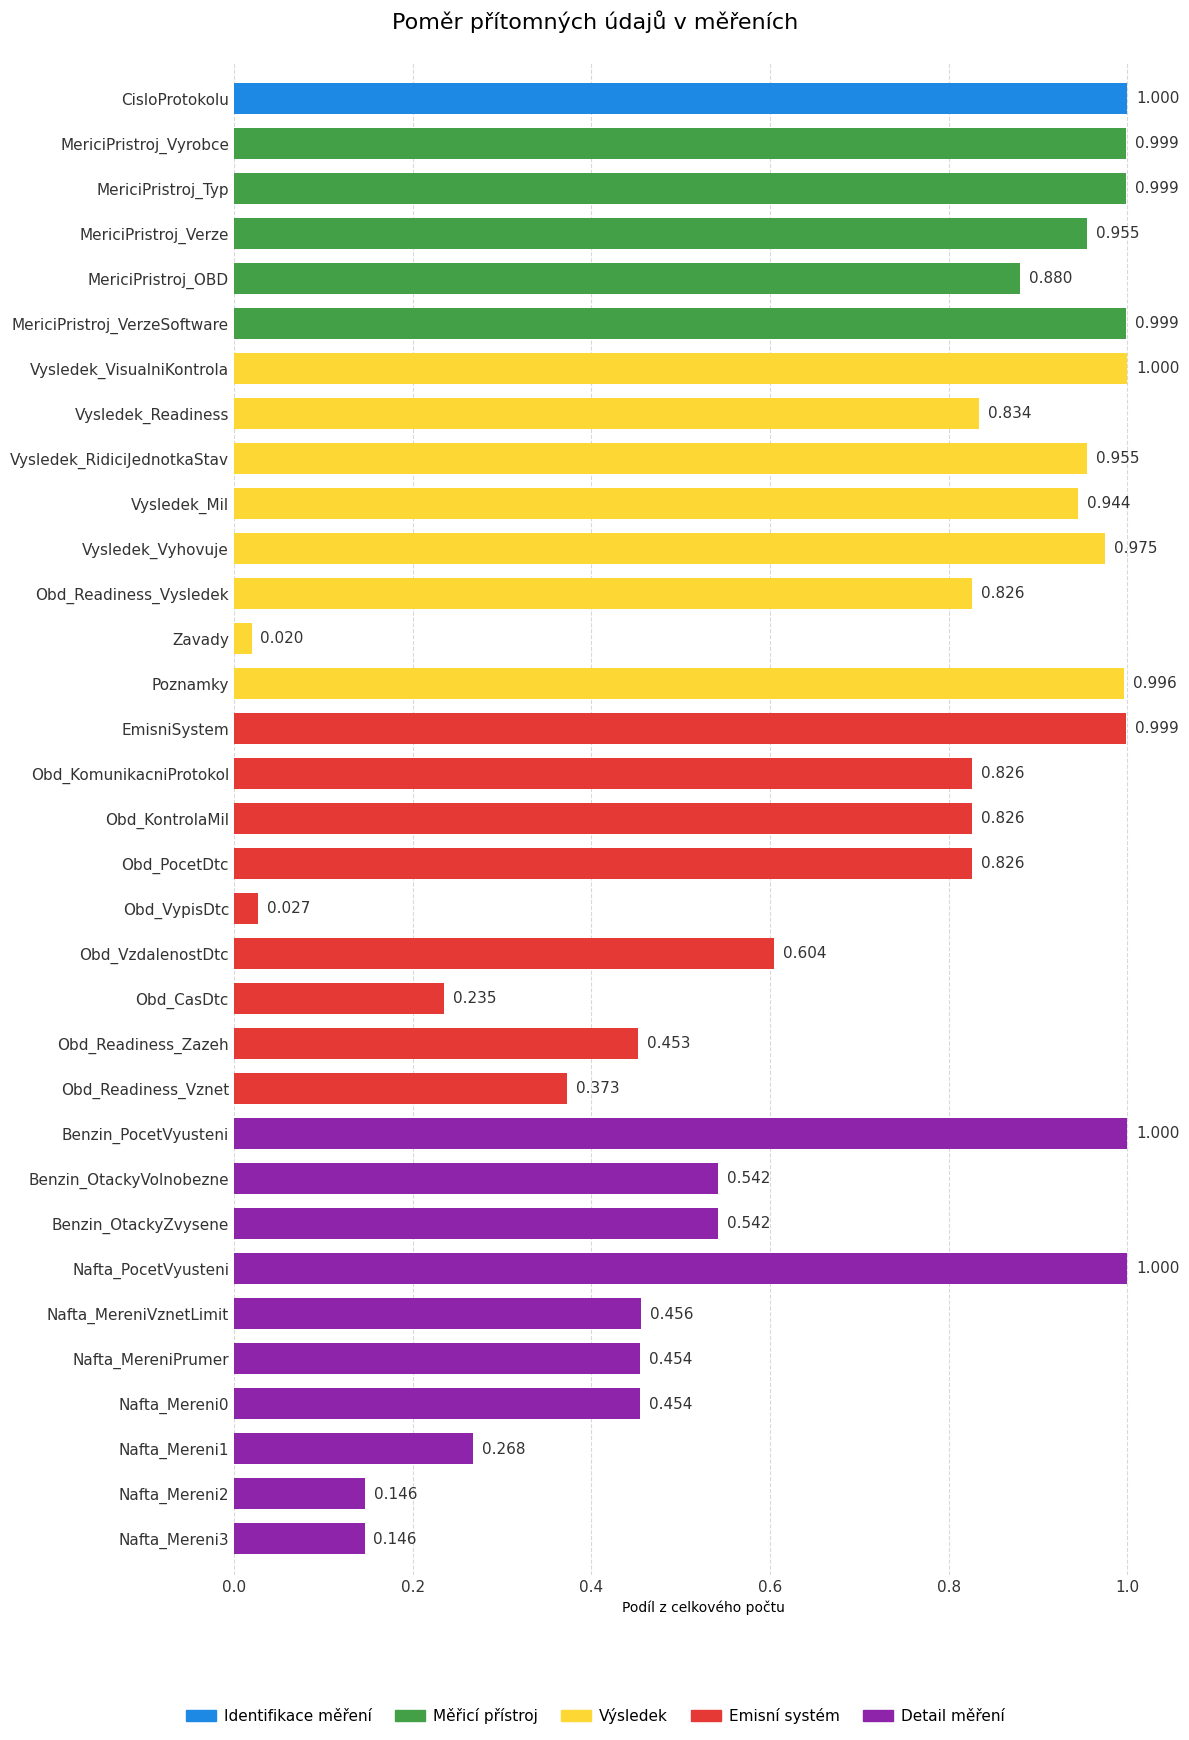

In [14]:
if PRINT: 
    # Definice agregačních skupin
    aggregation_groups = {
        'Obd_Readiness_Zazeh': [c for c in df.columns if 'Obd_Readiness_Zazeh' in c],
        'Obd_Readiness_Vznet': [c for c in df.columns if 'Obd_Readiness_Vznet' in c],
        'Benzin_OtackyVolnobezne': [c for c in df.columns if c.startswith('Benzin_OtackyVolnobezne_')],
        'Benzin_OtackyZvysene': [c for c in df.columns if c.startswith('Benzin_OtackyZvysene_')],
        'Nafta_MereniVznetLimit': [c for c in df.columns if c.startswith('Nafta_MereniVznetLimit_')],
        'Nafta_MereniPrumer': [c for c in df.columns if c.startswith('Nafta_MereniPrumer_')],
        'Nafta_Mereni0': [c for c in df.columns if c.startswith('Nafta_Mereni0_')],
        'Nafta_Mereni1': [c for c in df.columns if c.startswith('Nafta_Mereni1_')],
        'Nafta_Mereni2': [c for c in df.columns if c.startswith('Nafta_Mereni2_')],
        'Nafta_Mereni3': [c for c in df.columns if c.startswith('Nafta_Mereni3_')],
    }

    # Inverzní mapování: sloupec -> název skupiny
    col_to_group = {col: g_name for g_name, g_cols in aggregation_groups.items() for col in g_cols}

    # Výpočet metrik se zachováním pořadí z df.columns
    total_rows = len(df)
    final_labels = []
    final_ratios = []
    processed_groups = set()

    for col in df.columns:
        if col in col_to_group:
            group_name = col_to_group[col]
            if group_name not in processed_groups:
                # Výpočet pro celou skupinu (aspoň jedna ne-null hodnota)
                group_cols = aggregation_groups[group_name]
                any_present_count = df.select(
                    pl.any_horizontal(pl.col(group_cols).is_not_null())
                ).sum().item()
                final_labels.append(group_name)
                final_ratios.append(any_present_count / total_rows if total_rows > 0 else 0)
                processed_groups.add(group_name)
        else:
            # Samostatný sloupec
            non_null_count = total_rows - df[col].null_count()
            final_labels.append(col)
            final_ratios.append(non_null_count / total_rows if total_rows > 0 else 0)

    # Kategorizace (6 skupin včetně Vozidla)
    group_descriptions = [
        'Identifikace měření',
        'Měřicí přístroj',
        'Výsledek',  
        'Emisní systém', 
        'Detail měření'  
    ]

    def map_to_main_category(label):
        if label == 'CisloProtokolu': return 0
        if label.startswith('MericiPristroj'): return 1
        if any(x in label for x in ['Vysledek', 'PristiProhlidka', 'Zavady', 'Poznamky']): return 2
        if label.startswith('EmisniSystem') or label.startswith('Obd'): return 3
        if label.startswith('Benzin') or label.startswith('Nafta'): return 4
        return 3

    group_indices = [map_to_main_category(l) for l in final_labels]

    # Generování grafu
    horizontal_bar(
        labels=final_labels, 
        counts=final_ratios, 
        title='Poměr přítomných údajů v měřeních', 
        save_path='kod/explorace/mereni_grafy/mereni_pritomnost.svg', 
        decimals=3, 
        height=18, 
        group_indices=group_indices, 
        group_descriptions=group_descriptions
    )

### Emisni systemy

In [15]:
if PRINT: display(df['EmisniSystem'].value_counts(sort=True).with_columns(pl.col('count') / df.height))

EmisniSystem,count
enum,f64
"""Rizeny_Obd""",0.825958
"""Rizeny""",0.159702
"""Nerizeny""",0.01312
null,0.00122


### Pocet mereni u nafty

In [16]:
if PRINT: 
    print(f'Pomer dieselu, co ma alespon 2 mereni: {0.264 / 0.456 * 100:.2f} %')
    print(f'Pomer dieselu, co ma 3 a 4 mereni: {0.146 / 0.456 * 100:.2f} %')

Pomer dieselu, co ma alespon 2 mereni: 57.89 %
Pomer dieselu, co ma 3 a 4 mereni: 32.02 %


# Ulozeni dat

In [17]:
if PRINT: schema_description(df)
df.write_parquet(r"kod\data\processed\mereni_tmp.parquet")

,column,majority_class,majority_cnt,null,dtype
0,CisloProtokolu,CZ-461129-19-08-0154,1 / 16 211 224,0 / 16 211 224,String
1,MericiPristroj_Vyrobce,Bosch,5 375 898 / 16 211 224,19 781 / 16 211 224,String
2,MericiPristroj_Typ,AT505,2 376 466 / 16 211 224,19 781 / 16 211 224,String
3,MericiPristroj_Verze,-,5 642 738 / 16 211 224,723 589 / 16 211 224,String
4,MericiPristroj_OBD,R+OBD,3 262 784 / 16 211 224,1 942 264 / 16 211 224,String
...,...,...,...,...,...
196,Nafta_Mereni3_OtackyVolnobezne_Vysledek,1,2 370 450 / 16 211 224,13 839 884 / 16 211 224,Int8
197,Nafta_Mereni3_TPS_Hodnota,0.0,1 250 177 / 16 211 224,14 578 098 / 16 211 224,Float32
198,Nafta_Mereni3_TPS_Vysledek,2,1 597 033 / 16 211 224,14 578 098 / 16 211 224,Int8
199,Nafta_Mereni3_Teplota_Hodnota,0.0,425 610 / 16 211 224,14 244 049 / 16 211 224,Float32


In [3]:
df = pl.read_parquet(r"kod\data\processed\mereni_tmp.parquet")

## Pro dalsi analyzu uvazovany pouze Rizene emisni systemy
- odstraneny i zaznamy, ktere maji skoro same null (pro analyzu vsak mene relevantni - pouze jako vysledek)
- diky tomu neni mereno HC

In [19]:
if PRINT: print(f'Podil rizenych: {df['EmisniSystem'].value_counts().filter(pl.col('EmisniSystem').cast(pl.String).str.contains('Rizeny'))['count'].sum() / df.height * 100:.2f} %')
df_small = df.filter(pl.col('EmisniSystem').cast(pl.String).str.contains('Rizeny'))
# EmisniSystem uz obsahoval pouze 2 hodnoty
df_small = df_small.with_columns(pl.col('EmisniSystem') == 'Rizeny_Obd').rename({'EmisniSystem': 'OBD_Pritomno'})

Podil rizenych: 98.57 %


# Odstraneni chybnych zaznamu
## Zaporne hodnoty

In [20]:
if PRINT:
    # Filtrace a výpis vzorku (ponecháno pro logiku výpisu řádků)
    df_negative = df_small.filter(pl.any_horizontal(cs.numeric() < 0))
    print(f'Pocet zaznamu se zapornou hodnou: {df_negative.height}')
    
    for row in df_negative.head(5).iter_rows(named=True):
        negatives = [f"{k}: {v}" for k, v in row.items() if isinstance(v, (int, float)) and v < 0]
        print(f"{row['CisloProtokolu']}: {', '.join(negatives)}")

    # Efektivní agregace počtu záporných hodnot
    negative_counts = (
        df_small.select(
            (cs.numeric() < 0).sum()
        )
        .unpivot(variable_name="sloupec", value_name="pocet_zapornych")
        .filter(pl.col("pocet_zapornych") > 0)
        .sort("pocet_zapornych", descending=True)
    )
    display(negative_counts.to_pandas())

df_small = df_small.filter(pl.any_horizontal(~(cs.numeric() < 0)))

Pocet zaznamu se zapornou hodnou: 7341
CZ-560703-24-08-0203: Benzin_OtackyZvysene_O2_Hodnota: -0.019999999552965164
CZ-410102-19-12-0020: Benzin_OtackyVolnobezne_O2_Hodnota: -0.20000000298023224, Benzin_OtackyZvysene_O2_Hodnota: -0.4000000059604645
CZ-471008-22-05-0556: Benzin_OtackyVolnobezne_O2_Hodnota: -0.03999999910593033, Benzin_OtackyZvysene_O2_Hodnota: -0.03999999910593033
CZ-410102-19-02-0013: Benzin_OtackyZvysene_O2_Hodnota: -0.20000000298023224
CZ-560703-25-06-0285: Benzin_OtackyVolnobezne_O2_Hodnota: -0.05999999865889549, Benzin_OtackyZvysene_O2_Hodnota: -0.05999999865889549


,sloupec,pocet_zapornych
0,Benzin_OtackyZvysene_O2_Hodnota,6043
1,Benzin_OtackyVolnobezne_O2_Hodnota,3438
2,Benzin_OtackyVolnobezne_HC_Hodnota,187
3,Benzin_OtackyVolnobezne_CO_Hodnota,142
4,Benzin_OtackyZvysene_HC_Hodnota,123
5,Benzin_OtackyZvysene_CO_Hodnota,86
6,Benzin_OtackyVolnobezne_COCOOR_Hodnota,1
7,Benzin_OtackyVolnobezne_NOX_Hodnota,1
8,Benzin_OtackyZvysene_COCOOR_Hodnota,1
9,Benzin_OtackyZvysene_NOX_Hodnota,1


## Filtrace zaznamu predstavujicich konkretni mereni pro benzin nebo naftu

In [21]:
required_benzin = [
    # Benzin Vždy (Volnoběžné)
    "Benzin_OtackyVolnobezne_CO_Hodnota",
    "Benzin_OtackyVolnobezne_CO_Max_Hodnota",
    "Benzin_OtackyVolnobezne_N_Hodnota",
    "Benzin_OtackyVolnobezne_N_Min_Hodnota",
    "Benzin_OtackyVolnobezne_N_Max_Hodnota",
    
    # Benzin Zvýšené
    "Benzin_OtackyZvysene_LAMBDA_Hodnota",
    "Benzin_OtackyZvysene_LAMBDA_Min_Hodnota",
    "Benzin_OtackyZvysene_LAMBDA_Max_Hodnota",
    "Benzin_OtackyZvysene_CO_Max_Hodnota",
    "Benzin_OtackyZvysene_N_Hodnota",
    "Benzin_OtackyZvysene_N_Min_Hodnota",
    "Benzin_OtackyZvysene_N_Max_Hodnota"
]

required_nafta = [
    # Nafta Průměr
    "Nafta_MereniPrumer_CasAkcelerace_Hodnota",
    "Nafta_MereniPrumer_Kourivost_Hodnota",
    "Nafta_MereniPrumer_OtackyVolnobezne_Hodnota",
    "Nafta_MereniPrumer_OtackyPrebehove_Hodnota",
    
    # Nafta Limit Max
    "Nafta_MereniVznetLimit_CasAkcelerace_Max_Hodnota",
    "Nafta_MereniVznetLimit_Kourivost_Max_Hodnota",
    "Nafta_MereniVznetLimit_OtackyVolnobezne_Max_Hodnota",
    "Nafta_MereniVznetLimit_OtackyPrebehove_Max_Hodnota",
    
    # Nafta Limit Min
    "Nafta_MereniVznetLimit_OtackyVolnobezne_Min_Hodnota",
    "Nafta_MereniVznetLimit_OtackyPrebehove_Min_Hodnota"
]

benzin_mask = pl.all_horizontal(pl.col(required_benzin).is_not_null())
nafta_mask = pl.all_horizontal(pl.col(required_nafta).is_not_null())
if PRINT:
    # Filtrace na vyhovující měření před analýzou
    mask_ok = pl.col("Vysledek_Vyhovuje").fill_null(False) == True
    df_ok = df_small.filter(mask_ok)
    n_ok = df_ok.height

    # Filtrace neúplných záznamů pouze z vyhovujících
    df_partial = df_ok.filter(~(benzin_mask | nafta_mask))
    
    print(f'Podíl neúplných záznamů (v rámci vyhovujících): {df_partial.height / n_ok * 100:.4f} %')
    print(f'Počet záznamů s benzinem i naftou (v rámci vyhovujících): {df_ok.filter((pl.col("Nafta_PocetVyusteni") > 0) & (pl.col("Benzin_PocetVyusteni") > 0)).height}')

    # Analýza kategorií v rámci vyhovujících
    benzin_all_null = pl.all_horizontal(pl.col(required_benzin).is_null())
    nafta_all_null = pl.all_horizontal(pl.col(required_nafta).is_null())
    
    vse_chybi_count = df_partial.filter(benzin_all_null & nafta_all_null).height
    print(f'\nChybí úplně vše (benzin i nafta) u vyhovujících: {vse_chybi_count / n_ok * 100:.4f} %')

    def display_partial_stats(df, columns, label, n_total):
        # Filtrace na záznamy s aspoň jednou chybějící hodnotou, ale ne všemi
        is_partial = pl.any_horizontal(pl.col(columns).is_null()) & ~pl.all_horizontal(pl.col(columns).is_null())
        df_p = df.filter(is_partial)
        n_group = df_p.height
        
        # Výpis podílu této skupiny vůči všem vyhovujícím
        print(f'\nČástečně chybějící {label} u vyhovujících: {n_group / n_total * 100:.4f} %')
        
        if n_group > 0:
            # Agregace chybějících hodnot převedená na Polars DataFrame pro Data Wrangler
            stats = (
                df_p.select(pl.col(columns).null_count())
                .unpivot(variable_name="sloupec", value_name="chybi_pocet")
                .filter(pl.col("chybi_pocet") > 0)
                .with_columns(
                    podil_v_skupine_pct = (pl.col("chybi_pocet") / n_group * 100).round(2)
                )
                .sort("chybi_pocet", descending=True)
            )
            display(stats)

    # Detailní statistiky pro specifické podskupiny vyhovujících měření
    display_partial_stats(df_partial, required_benzin, "BENZÍN", n_ok)
    display_partial_stats(df_partial, required_nafta, "NAFTA", n_ok)

df_small = df_small.filter(benzin_mask | nafta_mask)

Podíl neúplných záznamů (v rámci vyhovujících): 0.0097 %
Počet záznamů s benzinem i naftou (v rámci vyhovujících): 0

Chybí úplně vše (benzin i nafta) u vyhovujících: 0.0021 %

Částečně chybějící BENZÍN u vyhovujících: 0.0055 %


sloupec,chybi_pocet,podil_v_skupine_pct
str,u32,f64
"""Benzin_OtackyVolnobezne_N_Hodn…",858,100.0
"""Benzin_OtackyVolnobezne_N_Min_…",858,100.0
"""Benzin_OtackyVolnobezne_N_Max_…",858,100.0
"""Benzin_OtackyZvysene_N_Hodnota""",846,98.6
"""Benzin_OtackyZvysene_N_Min_Hod…",846,98.6
…,…,…
"""Benzin_OtackyVolnobezne_CO_Max…",7,0.82
"""Benzin_OtackyZvysene_LAMBDA_Ho…",1,0.12
"""Benzin_OtackyZvysene_LAMBDA_Mi…",1,0.12



Částečně chybějící NAFTA u vyhovujících: 0.0021 %


sloupec,chybi_pocet,podil_v_skupine_pct
str,u32,f64
"""Nafta_MereniPrumer_CasAkcelera…",323,100.0
"""Nafta_MereniPrumer_Kourivost_H…",323,100.0
"""Nafta_MereniPrumer_OtackyVolno…",323,100.0
"""Nafta_MereniPrumer_OtackyPrebe…",323,100.0


## Kontrola limitu
### Benzin

In [22]:
limits_bounds_benzin = [
    # (Název atributu limitu, Očekávané MIN limitu, Očekávané MAX limitu)
    ('Benzin_OtackyVolnobezne_CO_Max_Hodnota', 0.05, 5.0),
    ('Benzin_OtackyVolnobezne_N_Min_Hodnota', 300, 3000),
    ('Benzin_OtackyVolnobezne_N_Max_Hodnota', 300, 3000),
    ('Benzin_OtackyZvysene_CO_Max_Hodnota', 0.01, 1.0),
    ('Benzin_OtackyZvysene_LAMBDA_Min_Hodnota', 0.9, 1.00),
    ('Benzin_OtackyZvysene_LAMBDA_Max_Hodnota', 1.00, 1.1),
    ('Benzin_OtackyZvysene_N_Min_Hodnota', 1000, 10000),
    ('Benzin_OtackyZvysene_N_Max_Hodnota', 1000, 10000)
]

for limit_bound in limits_bounds_benzin:
    if PRINT: print(f'Podil hodnot mimo limit pro {limit_bound[0]}: {df_small.filter(~pl.col(limit_bound[0]).is_between(limit_bound[1], limit_bound[2])).height / df_small.height * 100:.2f} %.')

for limit_bound in limits_bounds_benzin:
    df_small = df_small.filter(pl.col(limit_bound[0]).is_between(limit_bound[1], limit_bound[2]) | nafta_mask)

Podil hodnot mimo limit pro Benzin_OtackyVolnobezne_CO_Max_Hodnota: 0.05 %.
Podil hodnot mimo limit pro Benzin_OtackyVolnobezne_N_Min_Hodnota: 0.01 %.
Podil hodnot mimo limit pro Benzin_OtackyVolnobezne_N_Max_Hodnota: 0.01 %.
Podil hodnot mimo limit pro Benzin_OtackyZvysene_CO_Max_Hodnota: 0.03 %.
Podil hodnot mimo limit pro Benzin_OtackyZvysene_LAMBDA_Min_Hodnota: 0.09 %.
Podil hodnot mimo limit pro Benzin_OtackyZvysene_LAMBDA_Max_Hodnota: 0.10 %.
Podil hodnot mimo limit pro Benzin_OtackyZvysene_N_Min_Hodnota: 0.01 %.
Podil hodnot mimo limit pro Benzin_OtackyZvysene_N_Max_Hodnota: 0.01 %.


### Nafta

In [23]:
limits_bounds_nafta = [
    # (Název atributu limitu, Očekávané MIN limitu, Očekávané MAX limitu)
    ('Nafta_MereniVznetLimit_CasAkcelerace_Max_Hodnota', 0.1, 10.0),
    ('Nafta_MereniVznetLimit_Kourivost_Max_Hodnota', 0.01, 3.0),
    ('Nafta_MereniVznetLimit_OtackyVolnobezne_Min_Hodnota', 300, 3000),
    ('Nafta_MereniVznetLimit_OtackyVolnobezne_Max_Hodnota', 300, 3000),
    ('Nafta_MereniVznetLimit_OtackyPrebehove_Min_Hodnota', 1000, 10000),
    ('Nafta_MereniVznetLimit_OtackyPrebehove_Max_Hodnota', 1000, 10000)
]

for limit_bound in limits_bounds_nafta:
    if PRINT: print(f'Podil hodnot mimo limit pro {limit_bound[0]}: {df_small.filter(~pl.col(limit_bound[0]).is_between(limit_bound[1], limit_bound[2])).height / df_small.height * 100:.2f} %.')

for limit_bound in limits_bounds_nafta:
    df_small = df_small.filter(pl.col(limit_bound[0]).is_between(limit_bound[1], limit_bound[2]) | benzin_mask)

Podil hodnot mimo limit pro Nafta_MereniVznetLimit_CasAkcelerace_Max_Hodnota: 0.00 %.
Podil hodnot mimo limit pro Nafta_MereniVznetLimit_Kourivost_Max_Hodnota: 0.96 %.
Podil hodnot mimo limit pro Nafta_MereniVznetLimit_OtackyVolnobezne_Min_Hodnota: 0.00 %.
Podil hodnot mimo limit pro Nafta_MereniVznetLimit_OtackyVolnobezne_Max_Hodnota: 0.00 %.
Podil hodnot mimo limit pro Nafta_MereniVznetLimit_OtackyPrebehove_Min_Hodnota: 0.00 %.
Podil hodnot mimo limit pro Nafta_MereniVznetLimit_OtackyPrebehove_Max_Hodnota: 0.00 %.


### Nesmyslne delky intervalu

In [24]:
# Seznam dvojic limitů pro kontrolu integrity
check_limits_integrity = [
    ("Benzin_OtackyVolnobezne_N_Min_Hodnota", "Benzin_OtackyVolnobezne_N_Max_Hodnota"),
    ("Benzin_OtackyZvysene_LAMBDA_Min_Hodnota", "Benzin_OtackyZvysene_LAMBDA_Max_Hodnota"),
    ("Benzin_OtackyZvysene_N_Min_Hodnota", "Benzin_OtackyZvysene_N_Max_Hodnota"),
    ("Nafta_MereniVznetLimit_OtackyVolnobezne_Min_Hodnota", "Nafta_MereniVznetLimit_OtackyVolnobezne_Max_Hodnota"),
    ("Nafta_MereniVznetLimit_OtackyPrebehove_Min_Hodnota", "Nafta_MereniVznetLimit_OtackyPrebehove_Max_Hodnota")
]

for min_col, max_col in check_limits_integrity:
    if PRINT: print(f'Pocet hodnot se zapornou nebo nulovou delkou intervalu {min_col}, {max_col}: {df_small.filter(pl.col(min_col) >= pl.col(max_col)).height}')
    df_small = df_small.filter((pl.col(min_col).ne(pl.col(max_col))).fill_null(True))

Pocet hodnot se zapornou nebo nulovou delkou intervalu Benzin_OtackyVolnobezne_N_Min_Hodnota, Benzin_OtackyVolnobezne_N_Max_Hodnota: 17
Pocet hodnot se zapornou nebo nulovou delkou intervalu Benzin_OtackyZvysene_LAMBDA_Min_Hodnota, Benzin_OtackyZvysene_LAMBDA_Max_Hodnota: 5
Pocet hodnot se zapornou nebo nulovou delkou intervalu Benzin_OtackyZvysene_N_Min_Hodnota, Benzin_OtackyZvysene_N_Max_Hodnota: 194
Pocet hodnot se zapornou nebo nulovou delkou intervalu Nafta_MereniVznetLimit_OtackyVolnobezne_Min_Hodnota, Nafta_MereniVznetLimit_OtackyVolnobezne_Max_Hodnota: 21
Pocet hodnot se zapornou nebo nulovou delkou intervalu Nafta_MereniVznetLimit_OtackyPrebehove_Min_Hodnota, Nafta_MereniVznetLimit_OtackyPrebehove_Max_Hodnota: 85


## Filtrace pouze uspesnych mereni

In [25]:
if PRINT: print(f'Podil uspesnych: {df_small.filter(pl.col('Vysledek_Vyhovuje') == True).height / df_small.height * 100:.2f} %')
df_small = df_small.filter(pl.col('Vysledek_Vyhovuje') == True).drop('Vysledek_Vyhovuje')

Podil uspesnych: 97.86 %


# Extrakce dulezitych informaci

## Normalizace hodnot

In [26]:
# Definice mapování pro normalizaci
all_mappings = [
    ("Benzin_OtackyVolnobezne_CO_Hodnota", None, "Benzin_OtackyVolnobezne_CO_Max_Hodnota"),
    ("Benzin_OtackyVolnobezne_N_Hodnota", "Benzin_OtackyVolnobezne_N_Min_Hodnota", "Benzin_OtackyVolnobezne_N_Max_Hodnota"),
    ("Benzin_OtackyZvysene_LAMBDA_Hodnota", "Benzin_OtackyZvysene_LAMBDA_Min_Hodnota", "Benzin_OtackyZvysene_LAMBDA_Max_Hodnota"),
    ("Benzin_OtackyZvysene_CO_Hodnota", None, "Benzin_OtackyZvysene_CO_Max_Hodnota"),
    ("Benzin_OtackyZvysene_N_Hodnota", "Benzin_OtackyZvysene_N_Min_Hodnota", "Benzin_OtackyZvysene_N_Max_Hodnota"),
    ("Nafta_MereniPrumer_CasAkcelerace_Hodnota", None, "Nafta_MereniVznetLimit_CasAkcelerace_Max_Hodnota"),
    ("Nafta_MereniPrumer_Kourivost_Hodnota", None, "Nafta_MereniVznetLimit_Kourivost_Max_Hodnota"),
    ("Nafta_MereniPrumer_OtackyVolnobezne_Hodnota", "Nafta_MereniVznetLimit_OtackyVolnobezne_Min_Hodnota", "Nafta_MereniVznetLimit_OtackyVolnobezne_Max_Hodnota"),
    ("Nafta_MereniPrumer_OtackyPrebehove_Hodnota", "Nafta_MereniVznetLimit_OtackyPrebehove_Min_Hodnota", "Nafta_MereniVznetLimit_OtackyPrebehove_Max_Hodnota")
]

exprs = []
for val_col, min_col, max_col in all_mappings:
    low = pl.col(min_col) if min_col else pl.lit(0)
    high = pl.col(max_col)
    val = pl.col(val_col)
    
    # Normalizace
    norm_expr = ((val - low) / (high - low)).alias(f"{val_col}_Norm")
    exprs.append(norm_expr)

df_small = df_small.with_columns(exprs).drop((cs.starts_with('Benzin_') | cs.starts_with('Nafta_')) & (~cs.ends_with('PocetVyusteni')) & (~cs.ends_with('_Norm')))

## Spojeni informaci o mericim pristroji do Vyrobce a Typu

In [27]:
df_small = df_small.with_columns((pl.col('MericiPristroj_Vyrobce') + pl.col('MericiPristroj_Typ')).alias('MericiPristroj_Info')).drop(cs.contains("MericiPristroj") & (~cs.by_name("MericiPristroj_Info")))

## Pro nizkou ruznorodost ponechano pouze Obd_PocetDtc z DTC

In [28]:
df_small = df_small.drop(cs.contains('Dtc') & (~cs.by_name('Obd_PocetDtc')))

## Readiness podpory a otestovani prevedeno do poctu True

In [29]:
df_small = df_small.with_columns(pl.sum_horizontal(cs.ends_with("_Podporovano")).alias("Pocet_Podporovano"), pl.sum_horizontal(cs.ends_with("_Otestovano")).alias("Pocet_Otestovano"))
df_small = df_small.drop((cs.ends_with("_Podporovano") | cs.ends_with("_Otestovano")) & (~cs.by_name("Pocet_Podporovano")) & (~cs.by_name("Pocet_Otestovano")))

## Redukce seznamů na pocet prvku

In [30]:
df_small = df_small.with_columns(pl.col('Poznamky').list.len().fill_null(0), pl.col('Zavady').list.len().fill_null(0))

## Ulozeni mezivypoctu

In [31]:
df_small.write_parquet(r"kod\data\processed\mereni_small.parquet")

# Analyza zpracovaneho datasetu

In [2]:
df_small = pl.read_parquet(r'kod/data/processed/mereni_small.parquet')
df_benzin = df_small.filter(pl.col('Benzin_PocetVyusteni') > 0).select(cs.ends_with('_Norm') & cs.starts_with('Benzin_'))
df_nafta = df_small.filter(pl.col('Nafta_PocetVyusteni') > 0).select(cs.ends_with('_Norm') & cs.starts_with('Nafta_'))

## Rozdeleni a prazdne hodnoty

In [3]:
if PRINT:
    display(df_benzin.describe())
    display(df_nafta.describe())

statistic,Benzin_OtackyVolnobezne_CO_Hodnota_Norm,Benzin_OtackyVolnobezne_N_Hodnota_Norm,Benzin_OtackyZvysene_LAMBDA_Hodnota_Norm,Benzin_OtackyZvysene_CO_Hodnota_Norm,Benzin_OtackyZvysene_N_Hodnota_Norm
str,f64,f64,f64,f64,f64
"""count""",8.45662e6,8.45662e6,8.45662e6,8.45662e6,8.45662e6
"""null_count""",0.0,0.0,0.0,0.0,0.0
"""mean""",0.129237,0.513837,0.605703,0.32701,0.465711
"""std""",0.521411,0.22821,11.608143,0.400977,0.301378
"""min""",-0.54,-15.5,-33.000031,-0.2,-40.0
"""25%""",0.0,0.4,0.483334,0.05,0.255
"""50%""",0.036667,0.5,0.55,0.2,0.455
"""75%""",0.16,0.608,0.683334,0.566667,0.665
"""max""",920.0,144.5,17050.517578,633.333313,100.900002


statistic,Nafta_MereniPrumer_CasAkcelerace_Hodnota_Norm,Nafta_MereniPrumer_Kourivost_Hodnota_Norm,Nafta_MereniPrumer_OtackyVolnobezne_Hodnota_Norm,Nafta_MereniPrumer_OtackyPrebehove_Hodnota_Norm
str,f64,f64,f64,f64
"""count""",6.957884e6,6.957884e6,6.957884e6,6.957884e6
"""null_count""",0.0,0.0,0.0,0.0
"""mean""",0.203015,0.288662,0.441111,0.471831
"""std""",0.268422,3.778722,0.352477,0.782337
"""min""",0.0,0.0,-37.0,-103.0
"""25%""",0.0,0.019608,0.31,0.3625
"""50%""",0.188,0.155556,0.493333,0.5025
"""75%""",0.31,0.52,0.54,0.65
"""max""",400.0,9236.363281,77.0,220.399994


## Hodnoty mimo rozsah

In [4]:
def print_values_invalid(df):
    for col in df.columns:
        print(f'Relativni cetnost pozorovani {col} mimo rozsah <0, 1>: {df.filter(~pl.col(col).is_between(0, 1)).height / df.height * 100:.2f} %')

if PRINT:
    print_values_invalid(df_benzin)
    print_values_invalid(df_nafta)

Relativni cetnost pozorovani Benzin_OtackyVolnobezne_CO_Hodnota_Norm mimo rozsah <0, 1>: 0.00 %
Relativni cetnost pozorovani Benzin_OtackyVolnobezne_N_Hodnota_Norm mimo rozsah <0, 1>: 1.17 %
Relativni cetnost pozorovani Benzin_OtackyZvysene_LAMBDA_Hodnota_Norm mimo rozsah <0, 1>: 0.01 %
Relativni cetnost pozorovani Benzin_OtackyZvysene_CO_Hodnota_Norm mimo rozsah <0, 1>: 0.01 %
Relativni cetnost pozorovani Benzin_OtackyZvysene_N_Hodnota_Norm mimo rozsah <0, 1>: 3.38 %
Relativni cetnost pozorovani Nafta_MereniPrumer_CasAkcelerace_Hodnota_Norm mimo rozsah <0, 1>: 0.06 %
Relativni cetnost pozorovani Nafta_MereniPrumer_Kourivost_Hodnota_Norm mimo rozsah <0, 1>: 0.02 %
Relativni cetnost pozorovani Nafta_MereniPrumer_OtackyVolnobezne_Hodnota_Norm mimo rozsah <0, 1>: 0.82 %
Relativni cetnost pozorovani Nafta_MereniPrumer_OtackyPrebehove_Hodnota_Norm mimo rozsah <0, 1>: 1.73 %


### Nekdy je to zpusobeno spatnym zaokrouhlenim, jindy ne

In [5]:
if PRINT:
    df_kourivost_mimo = df_small.filter(~pl.col('Nafta_MereniPrumer_Kourivost_Hodnota_Norm').is_between(0, 1))
    short_display(df_kourivost_mimo)
    example_ids = df_kourivost_mimo['CisloProtokolu'][:10].to_list()
    short_display(pl.scan_parquet(r'kod\data\extracted\data_z_mericich_pristroju\parquet', schema=mereni_schema).select(pl.col('CisloProtokolu'), pl.col('^.*Kourivost.*$')).filter(pl.col('CisloProtokolu').is_in(example_ids)).collect(engine='streaming'))

(1079, 26)


,CisloProtokolu,Vysledek_VisualniKontrola,Vysledek_Readiness,Vysledek_RidiciJednotkaStav,Vysledek_Mil,Obd_Readiness_Vysledek,Zavady,Poznamky,OBD_Pritomno,Obd_KomunikacniProtokol,...,Benzin_OtackyZvysene_LAMBDA_Hodnota_Norm,Benzin_OtackyZvysene_CO_Hodnota_Norm,Benzin_OtackyZvysene_N_Hodnota_Norm,Nafta_MereniPrumer_CasAkcelerace_Hodnota_Norm,Nafta_MereniPrumer_Kourivost_Hodnota_Norm,Nafta_MereniPrumer_OtackyVolnobezne_Hodnota_Norm,Nafta_MereniPrumer_OtackyPrebehove_Hodnota_Norm,MericiPristroj_Info,Pocet_Podporovano,Pocet_Otestovano
0,CZ-472201-19-08-0233,True,True,NaN,2.0,None,0,3,False,None,...,NaN,NaN,NaN,0.454000,1.088889,0.400000,0.505000,BoschMTM-BEA,0,0
1,CZ-480935-21-04-0151,True,True,1.0,2.0,True,0,2,True,ISO K-Line,...,NaN,NaN,NaN,0.000000,1.020000,0.850000,0.875000,BoschBEA070,0,11
2,CZ-472201-19-09-0049,True,True,NaN,2.0,None,0,3,False,None,...,NaN,NaN,NaN,0.414000,1.142857,0.493333,0.457500,BoschMTM-BEA,0,0
3,CZ-510806-23-06-0376,True,True,NaN,2.0,None,0,1,False,None,...,NaN,NaN,NaN,0.320000,12.380000,0.333333,0.580000,AVL DiTEST GmbHAVL DiSmoke 480,0,0
4,CZ-520808-22-10-0194,True,True,1.0,2.0,True,0,1,True,ISO 15765,...,NaN,NaN,NaN,0.200000,1.485714,0.600000,0.487500,AVL DiTEST GmbHDSS OM-CZ,4,10
5,CZ-472201-20-01-0318,True,True,NaN,2.0,None,0,3,False,None,...,NaN,NaN,NaN,0.418000,1.057143,0.693333,0.262500,BoschMTM-BEA,0,0
6,CZ-450402-22-10-0215,True,None,1.0,2.0,None,0,4,False,None,...,NaN,NaN,NaN,0.360000,1.450000,0.300000,0.075000,MAHLEOPA-100,0,0
7,CZ-3328-23-02-0142,True,True,1.0,2.0,True,0,3,True,ISO 14230,...,NaN,NaN,NaN,0.508000,1.228571,0.350000,0.312500,AVL DiTEST GmbHAVL DiSmoke 480,3,11
8,CZ-470631-22-03-0511,True,True,1.0,2.0,True,0,5,True,ISO 15765,...,NaN,NaN,NaN,0.550000,1.240000,0.500000,0.423077,AVL DiTEST GmbHAVL DiSmoke 480,3,11
9,CZ-570228-20-05-0594,True,True,1.0,2.0,True,2,2,True,ISO 15765,...,NaN,NaN,NaN,0.000000,1.380000,0.500000,0.230769,AVL DiTEST GmbHAVL DiSmoke 480,1,11


(9, 15)


,CisloProtokolu,Nafta_MereniVznetLimit_Kourivost_Max_Hodnota,Nafta_MereniVznetLimit_Kourivost_Max_RucniZadani,Nafta_MereniVznetLimit_KourivostRozpeti_Max_Hodnota,Nafta_MereniVznetLimit_KourivostRozpeti_Max_RucniZadani,Nafta_MereniPrumer_Kourivost_Hodnota,Nafta_MereniPrumer_Kourivost_Vysledek,Nafta_Mereni0_Kourivost_Hodnota,Nafta_Mereni0_Kourivost_Vysledek,Nafta_Mereni1_Kourivost_Hodnota,Nafta_Mereni1_Kourivost_Vysledek,Nafta_Mereni2_Kourivost_Hodnota,Nafta_Mereni2_Kourivost_Vysledek,Nafta_Mereni3_Kourivost_Hodnota,Nafta_Mereni3_Kourivost_Vysledek
0,CZ-472201-19-09-0049,0.70,false,0.25,false,0.8,1,0.99,1,1.02,1,0.71,1,0.48,1
1,CZ-510806-23-06-0376,1,false,0.25,false,12.38,1,0.55,1,0.51,1,48.0,1,0.45,1
2,CZ-520808-22-10-0194,0.700,false,0.250,false,1.04,0,1.19,0,1.01,0,0.97,0,0.99,0
3,CZ-450402-22-10-0215,0.80,true,0.25,false,1.16,1,1.01,1,1.25,1,1.2,1,1.19,1
4,CZ-480935-21-04-0151,0.50,true,0.25,false,0.51,1,0.45,1,0.66,1,0.43,1,0.5,1
5,CZ-472201-19-08-0233,0.90,false,0.25,false,0.98,1,1.11,1,1.17,1,0.86,1,0.76,1
6,CZ-570228-20-05-0594,0.50,true,0.25,false,0.69,1,0.69,1,None,None,None,None,None,None
7,CZ-472201-20-01-0318,0.70,false,0.25,false,0.74,1,0.75,1,0.79,1,0.72,1,0.68,1
8,CZ-470631-22-03-0511,0.25,true,0.25,false,0.31,1,0.31,1,None,None,None,None,None,None


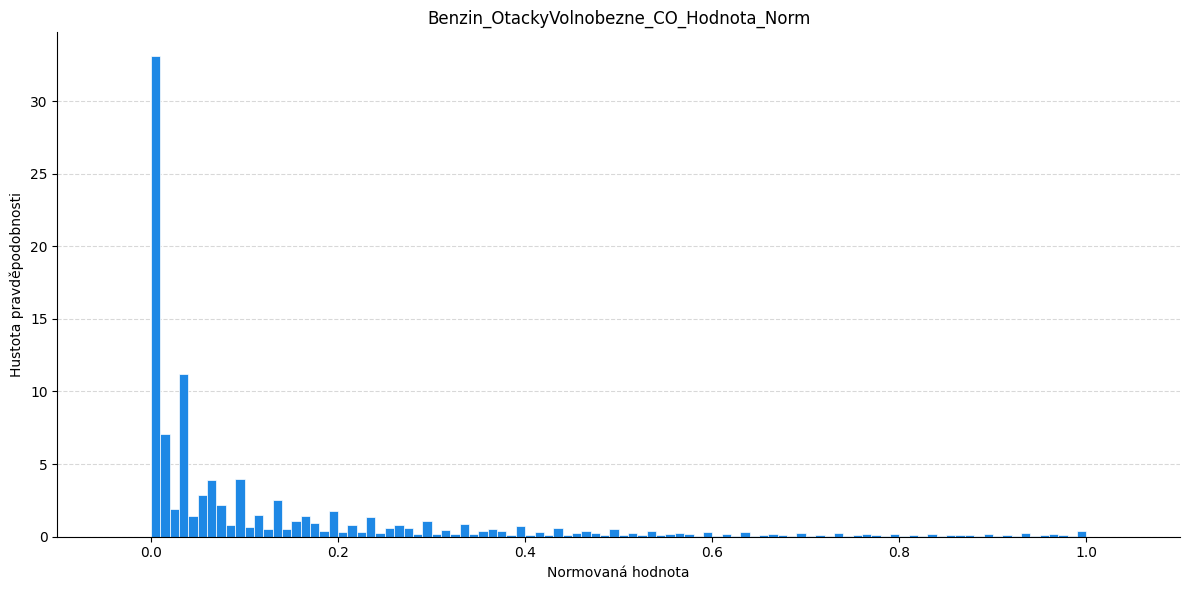

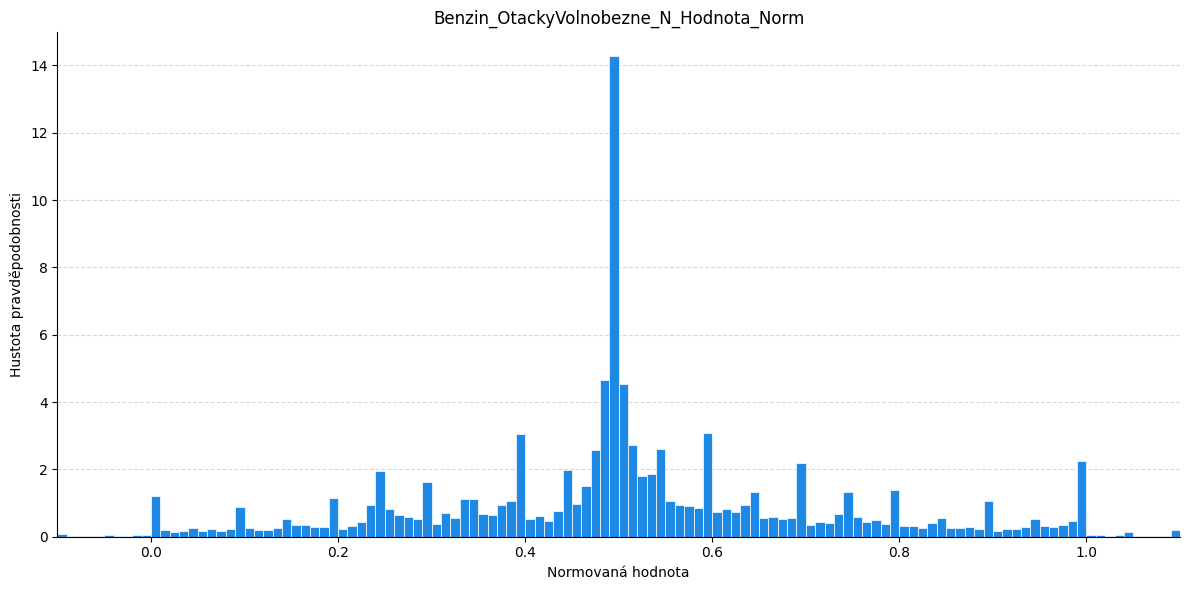

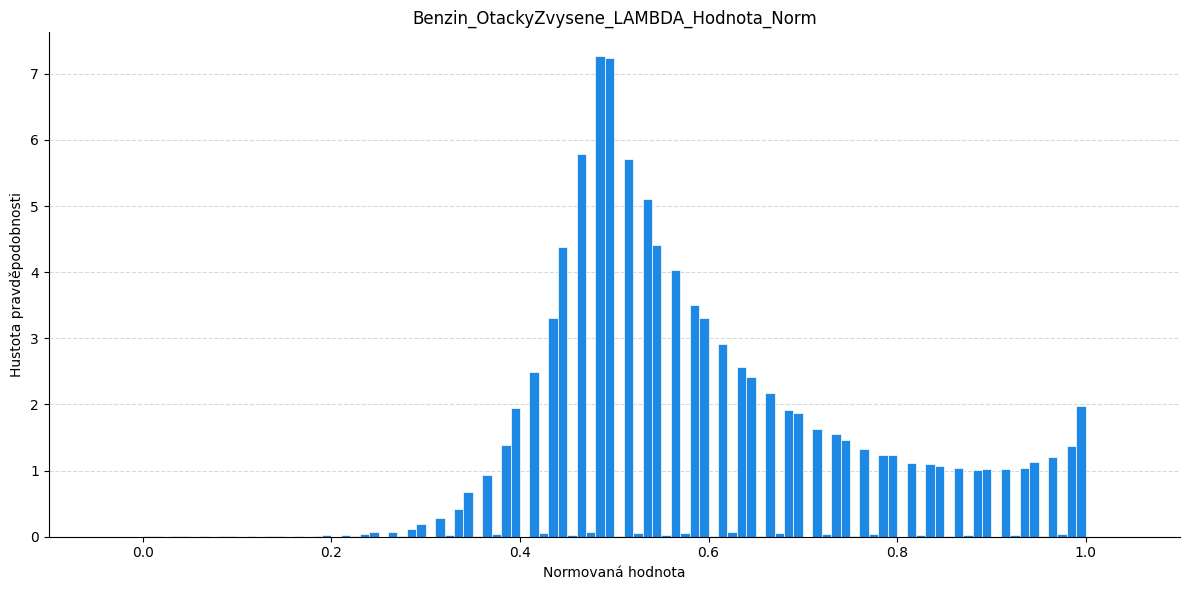

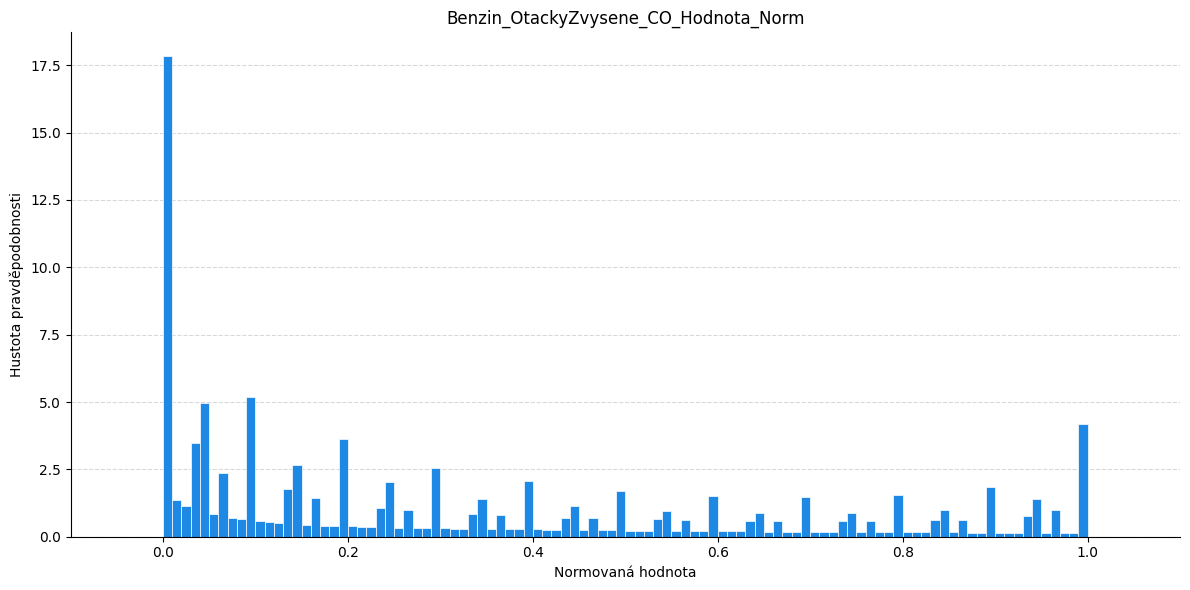

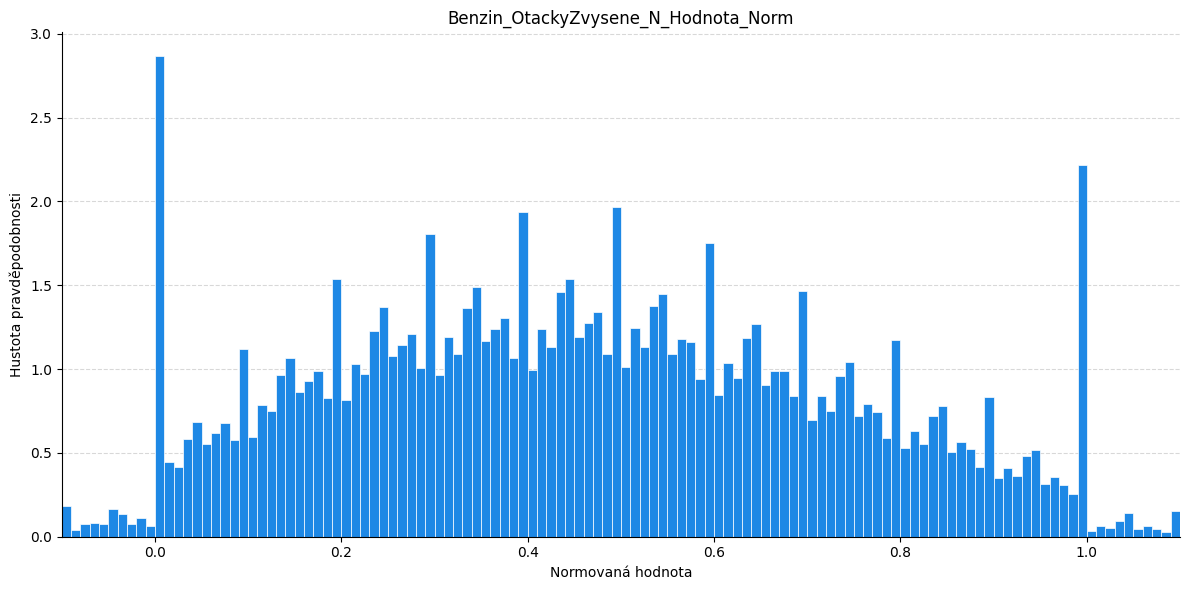

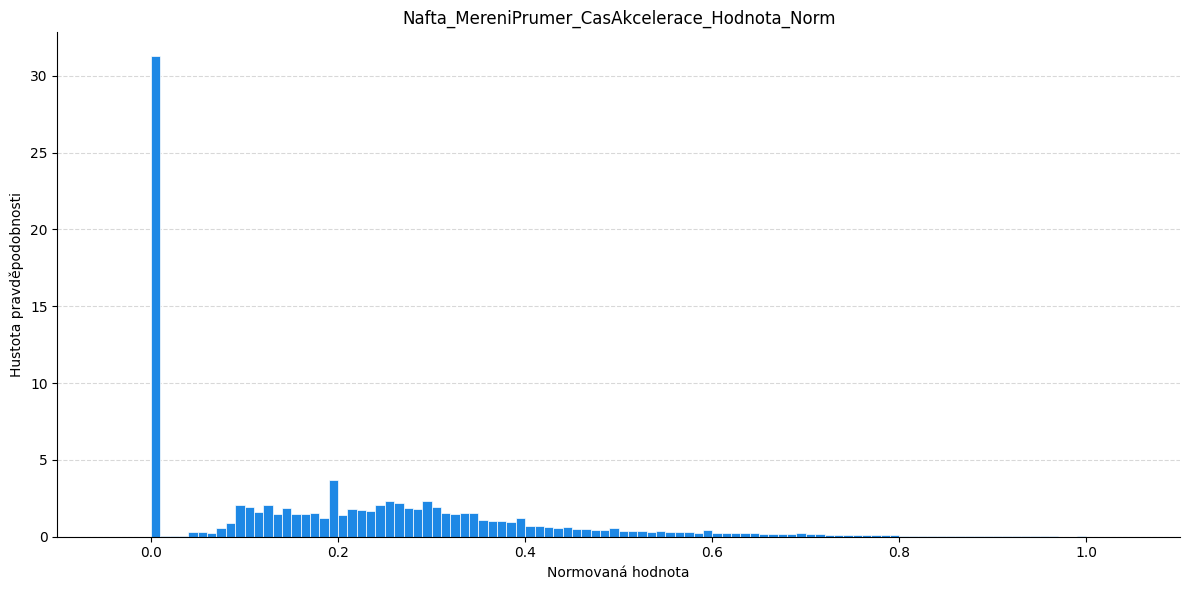

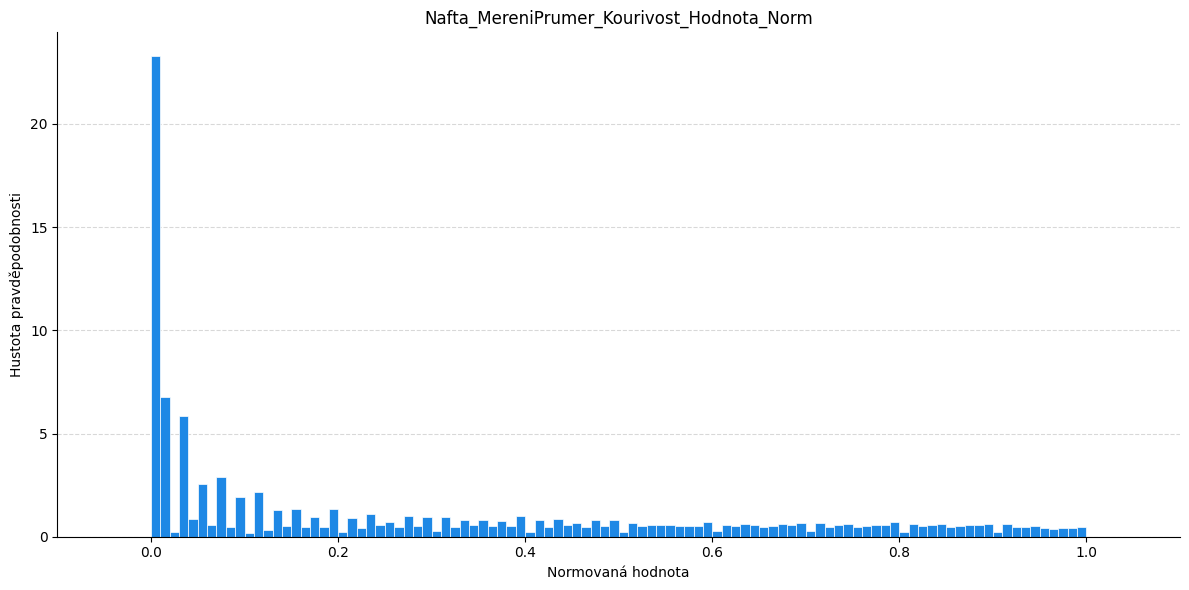

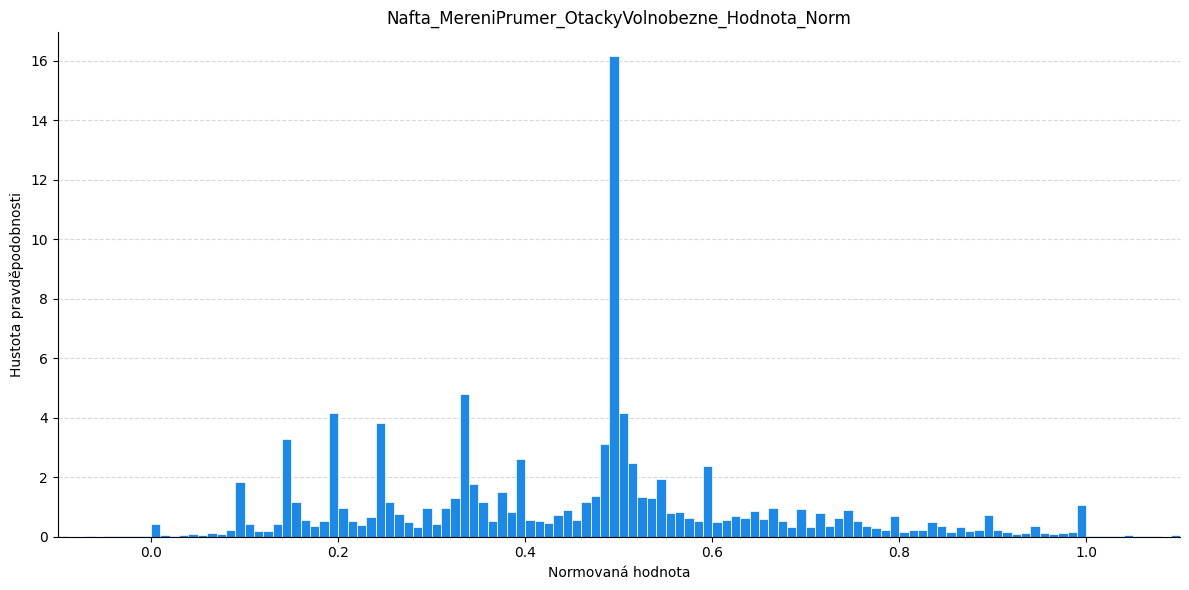

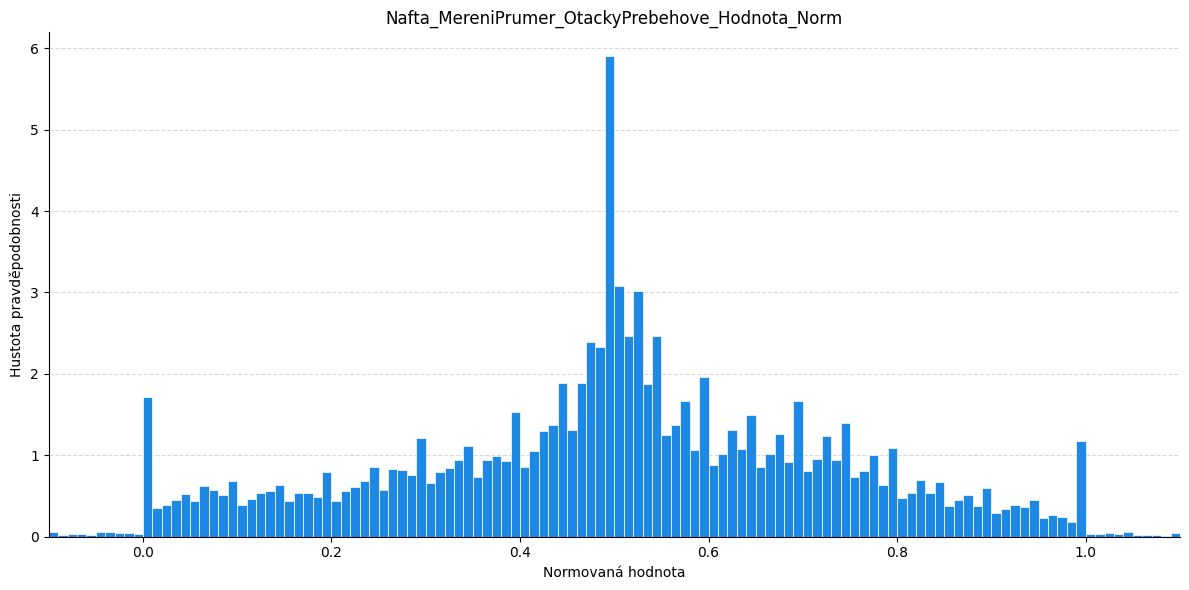

In [6]:
def plot_norms(df):
    for col in df.columns:
        distribution_density_plot(df.filter(pl.col(col).is_between(-0.1, 1.1)), col, col, 'Normovaná hodnota', 100, (0, 1.00001), save_path=f'kod/explorace/mereni_grafy/rozdeleni_{col}.svg')
plot_norms(df_benzin)
plot_norms(df_nafta)

# Ulozeni normovanych dat pro nanalyzu vyvoje

In [7]:
lf_time = pl.scan_parquet(r'kod\data\extracted\data_z_mericich_pristroju\parquet', schema=mereni_schema).select(['CisloProtokolu', 'Zahajeni'])
lf_time = df_small.lazy().join(lf_time, on='CisloProtokolu', how='left').with_columns(pl.col('Zahajeni').cast(pl.Datetime).alias('Date')).filter(pl.col('Date').is_not_null()).sort('Date')

lf_benzin_time = lf_time.select(['Date'] + df_benzin.columns).drop_nulls()
lf_nafta_time = lf_time.select(['Date'] + df_nafta.columns).drop_nulls()

lf_benzin_time.sink_parquet(r"kod\data\processed\normalized_benzin.parquet")
lf_nafta_time.sink_parquet(r"kod\data\processed\normalized_nafta.parquet")

if PRINT:
    display(lf_benzin_time.collect())
    display(lf_nafta_time.collect())

Date,Benzin_OtackyVolnobezne_CO_Hodnota_Norm,Benzin_OtackyVolnobezne_N_Hodnota_Norm,Benzin_OtackyZvysene_LAMBDA_Hodnota_Norm,Benzin_OtackyZvysene_CO_Hodnota_Norm,Benzin_OtackyZvysene_N_Hodnota_Norm
datetime[μs],f32,f32,f32,f32,f32
2019-01-02 05:49:57.690,0.008,0.633333,0.566666,0.053333,0.36
2019-01-02 05:56:06.387,0.233333,0.146667,0.45,1.0,0.505
2019-01-02 06:01:06.387,0.033333,0.5,0.5,0.2,0.2
2019-01-02 06:05:26.183,0.033333,0.25,0.516667,0.05,0.0
2019-01-02 06:08:22.210,0.02,0.45,0.933334,0.3,0.633333
…,…,…,…,…,…
2026-03-15 13:23:12.477,0.006667,0.466667,0.516667,0.24,0.505
2026-03-15 13:33:47.220,0.166667,0.975,0.466667,0.455,0.075
2026-03-15 14:36:24.230,0.0,0.475,0.483334,0.03,0.912


Date,Nafta_MereniPrumer_CasAkcelerace_Hodnota_Norm,Nafta_MereniPrumer_Kourivost_Hodnota_Norm,Nafta_MereniPrumer_OtackyVolnobezne_Hodnota_Norm,Nafta_MereniPrumer_OtackyPrebehove_Hodnota_Norm
datetime[μs],f32,f32,f32,f32
2019-01-01 14:43:55.020,0.0,0.195946,-0.02,-0.435
2019-01-02 05:30:13.650,0.0,0.0,0.5,0.6
2019-01-02 06:02:51.400,0.306,0.77,0.5,0.657143
2019-01-02 06:04:57.523,0.0,0.039216,0.665625,0.3175
2019-01-02 06:05:56.333,0.0,0.633333,0.25,1.55
…,…,…,…,…
2026-03-15 14:14:56.800,0.2,0.310345,0.28,0.925
2026-03-15 14:25:54.410,0.262,0.2,0.596667,0.176667
2026-03-15 14:55:13.493,0.302,0.08,0.59,0.3


# Finální příprava pro tvorbu modelu

## Sparovani pristich vysledku s merenimi

In [ ]:
lf_full = pl.scan_parquet(r'kod\data\extracted\data_z_mericich_pristroju\parquet', schema=mereni_schema).pipe(cast_mereni)

lf_shifted_result = (
    lf_full
    .select(["CisloProtokolu", "Vozidlo_Vin", "Zahajeni", "Vysledek_Vyhovuje"])
    .sort(["Vozidlo_Vin", "Zahajeni"])
    .with_columns(
        Vysledek_Pristi_Raw=pl.col("Vysledek_Vyhovuje").shift(-1).over("Vozidlo_Vin"),
        Pristi_Zaznam_Existuje=pl.col("CisloProtokolu").shift(-1).over("Vozidlo_Vin").is_not_null()
    )
    .with_columns(
        Vysledek_Pristi=pl.when(pl.col("Pristi_Zaznam_Existuje"))
        .then(pl.col("Vysledek_Pristi_Raw").fill_null(False))
        .otherwise(None)
    )
    .unique(subset=['CisloProtokolu'])
    .select(["CisloProtokolu", "Vysledek_Pristi"])
)

df_small = (df_small.lazy().join(lf_shifted_result, on="CisloProtokolu", how="left").collect())

## Odstraneni mereni, ktera nemaji znamy pristi vysledek

In [ ]:
if PRINT: display(df_small['Vysledek_Pristi'].value_counts())
df_small_model = df_small.filter(pl.col('Vysledek_Pristi').is_not_null())

Vysledek_Pristi,count
bool,u32
null,5697368
false,257041
true,9460095


# Aplikovani stejnych filtru na df jako na df_small_model

In [ ]:
df_model = df.join(df_small.select(['CisloProtokolu', 'Vysledek_Pristi']), on='CisloProtokolu', how='inner')
if PRINT:
    print(f'Delka df_small_model: {df_small_model.height}')
    print(f'Delka df_model:       {df_model.height}')

Delka df_model: 9717136
Delka df:       9717136


## Uprava nekterych sloupcu df do formatu vhodneho pro analyzu

In [ ]:
# Redukce seznamu na jejich pocet
df_model = df_model.with_columns(pl.col(pl.List).list.len().fill_null(0))
# Emisni system na pritomnost OBD
df_model = df_model.with_columns(pl.col('EmisniSystem') == 'Rizeny_Obd').rename({'EmisniSystem': 'OBD_Pritomno'})

# Ulozeni dat pro trenovani modelu

In [ ]:
df_small_model.write_parquet(r"kod\data\processed\mereni_model.parquet")
df_model.write_parquet(r"kod\data\processed\mereni_model_raw.parquet")

In [ ]:
if PRINT:
    describe(df_small_model)
    describe(df_model)

CisloProtokolu,Vysledek_VisualniKontrola,Vysledek_Readiness,Vysledek_RidiciJednotkaStav,Vysledek_Mil,Obd_Readiness_Vysledek,Zavady,Poznamky,OBD_Pritomno,Obd_KomunikacniProtokol,Obd_KontrolaMil,Obd_PocetDtc,Benzin_PocetVyusteni,Nafta_PocetVyusteni,Benzin_OtackyVolnobezne_CO_Hodnota_Norm,Benzin_OtackyVolnobezne_N_Hodnota_Norm,Benzin_OtackyZvysene_LAMBDA_Hodnota_Norm,Benzin_OtackyZvysene_CO_Hodnota_Norm,Benzin_OtackyZvysene_N_Hodnota_Norm,Nafta_MereniPrumer_CasAkcelerace_Hodnota_Norm,Nafta_MereniPrumer_Kourivost_Hodnota_Norm,Nafta_MereniPrumer_OtackyVolnobezne_Hodnota_Norm,Nafta_MereniPrumer_OtackyPrebehove_Hodnota_Norm,MericiPristroj_Info,Pocet_Podporovano,Pocet_Otestovano,Vysledek_Pristi
str,bool,bool,i8,i8,bool,u32,u32,bool,str,i8,i32,i8,i8,f32,f32,f32,f32,f32,f32,f32,f32,f32,str,u32,u32,bool
"""CZ-530104-23-12-0237""",true,false,1,2,true,0,4,true,"""ISO 15765""",2,0,0,1,null,null,null,null,null,0.376,0.34,0.333333,0.675,"""AVL DiTEST GmbHAVL DiSmoke 480""",8,10,true


(9717136, 27)


,CisloProtokolu,Vysledek_VisualniKontrola,Vysledek_Readiness,Vysledek_RidiciJednotkaStav,Vysledek_Mil,Obd_Readiness_Vysledek,Zavady,Poznamky,OBD_Pritomno,Obd_KomunikacniProtokol,...,Benzin_OtackyZvysene_CO_Hodnota_Norm,Benzin_OtackyZvysene_N_Hodnota_Norm,Nafta_MereniPrumer_CasAkcelerace_Hodnota_Norm,Nafta_MereniPrumer_Kourivost_Hodnota_Norm,Nafta_MereniPrumer_OtackyVolnobezne_Hodnota_Norm,Nafta_MereniPrumer_OtackyPrebehove_Hodnota_Norm,MericiPristroj_Info,Pocet_Podporovano,Pocet_Otestovano,Vysledek_Pristi
0,CZ-530104-23-12-0237,True,False,1.0,2.0,True,0,4,True,ISO 15765,...,NaN,NaN,0.3760,0.340000,0.333333,0.675000,AVL DiTEST GmbHAVL DiSmoke 480,8,10,True
1,CZ-481005-19-02-0061,True,None,1.0,2.0,None,0,4,False,None,...,NaN,NaN,0.0000,0.933333,0.413333,0.467500,BoschRTM430,0,0,True
2,CZ-450227-19-05-0393,True,False,1.0,2.0,True,0,3,True,ISO 14230,...,1.000000,0.383333,NaN,NaN,NaN,NaN,ActiaCZAT505,4,9,True
3,CZ-3706-21-06-1452,True,False,1.0,2.0,True,0,3,True,ISO 15765,...,NaN,NaN,0.0000,0.000000,0.500000,0.680000,ActiaCZAT605,6,7,True
4,CZ-440402-23-06-0444,True,True,1.0,2.0,True,0,1,True,ISO 15765,...,NaN,NaN,0.2000,0.000000,0.500000,0.600000,AVL DiTEST GmbHAVL DiSmoke 480,4,10,True
5,CZ-510410-20-07-0107,True,True,1.0,2.0,True,0,1,True,CAN (ISO 15765-4),...,NaN,NaN,0.0000,0.000000,0.175000,0.360000,BOSCHBEA-PC,4,11,True
6,CZ-480334-23-07-0121,True,True,1.0,2.0,True,0,2,True,ISO 15765,...,NaN,NaN,0.1720,0.000000,0.190000,0.392500,BoschBEA 950,8,11,True
7,CZ-460219-22-11-0220,True,False,1.0,2.0,True,0,2,True,ISO 15765,...,0.000000,-0.150000,NaN,NaN,NaN,NaN,AVL DiTEST GmbHAVL Gas 1000,8,6,True
8,CZ-421024-19-08-0407,True,True,1.0,2.0,True,0,3,True,ISO 9141,...,0.266667,0.050000,NaN,NaN,NaN,NaN,AVL DiTEST GmbHAVL Gas 1000,9,11,True
9,CZ-530107-19-04-0248,True,None,1.0,2.0,None,0,6,False,None,...,NaN,NaN,0.0000,0.622222,0.386667,0.500000,BRISKJT480A,0,0,True


,column,majority_class,majority_cnt,null,dtype
0,CisloProtokolu,CZ-430422-23-01-0219,1 / 9 717 136,0 / 9 717 136,String
1,Vysledek_VisualniKontrola,True,9 716 535 / 9 717 136,0 / 9 717 136,Boolean
2,Vysledek_Readiness,True,6 856 364 / 9 717 136,1 382 172 / 9 717 136,Boolean
3,Vysledek_RidiciJednotkaStav,1,9 330 490 / 9 717 136,313 087 / 9 717 136,Int8
4,Vysledek_Mil,2,9 289 514 / 9 717 136,423 169 / 9 717 136,Int8
5,Obd_Readiness_Vysledek,True,7 792 137 / 9 717 136,1 452 614 / 9 717 136,Boolean
6,Zavady,0,9 709 602 / 9 717 136,0 / 9 717 136,UInt32
7,Poznamky,2,3 288 703 / 9 717 136,0 / 9 717 136,UInt32
8,OBD_Pritomno,True,8 264 522 / 9 717 136,0 / 9 717 136,Boolean
9,Obd_KomunikacniProtokol,ISO 15765,3 395 136 / 9 717 136,1 452 614 / 9 717 136,String


CisloProtokolu,MericiPristroj_Vyrobce,MericiPristroj_Typ,MericiPristroj_Verze,MericiPristroj_OBD,MericiPristroj_VerzeSoftware,Vysledek_VisualniKontrola,Vysledek_Readiness,Vysledek_RidiciJednotkaStav,Vysledek_Mil,Vysledek_Vyhovuje,Obd_Readiness_Vysledek,Zavady,Poznamky,OBD_Pritomno,Obd_KomunikacniProtokol,Obd_KontrolaMil,Obd_PocetDtc,Obd_VypisDtc,Obd_VzdalenostDtc,Obd_CasDtc,Obd_Readiness_Zazeh_AC_Otestovano,Obd_Readiness_Zazeh_AC_Podporovano,Obd_Readiness_Zazeh_CAT-FUNC_Otestovano,Obd_Readiness_Zazeh_CAT-FUNC_Podporovano,Obd_Readiness_Zazeh_COMP_Otestovano,Obd_Readiness_Zazeh_COMP_Podporovano,Obd_Readiness_Zazeh_EGR-VVT_Otestovano,Obd_Readiness_Zazeh_EGR-VVT_Podporovano,Obd_Readiness_Zazeh_EVAP_Otestovano,Obd_Readiness_Zazeh_EVAP_Podporovano,Obd_Readiness_Zazeh_FUEL_Otestovano,Obd_Readiness_Zazeh_FUEL_Podporovano,Obd_Readiness_Zazeh_HCAT_Otestovano,Obd_Readiness_Zazeh_HCAT_Podporovano,Obd_Readiness_Zazeh_MISF_Otestovano,Obd_Readiness_Zazeh_MISF_Podporovano,Obd_Readiness_Zazeh_O2S-FUNC_Otestovano,Obd_Readiness_Zazeh_O2S-FUNC_Podporovano,Obd_Readiness_Zazeh_O2S-HEAT_Otestovano,Obd_Readiness_Zazeh_O2S-HEAT_Podporovano,Obd_Readiness_Zazeh_SAS_Otestovano,Obd_Readiness_Zazeh_SAS_Podporovano,Obd_Readiness_Vznet_AC_Otestovano,Obd_Readiness_Vznet_AC_Podporovano,Obd_Readiness_Vznet_BOOST_Otestovano,Obd_Readiness_Vznet_BOOST_Podporovano,Obd_Readiness_Vznet_COMP_Otestovano,Obd_Readiness_Vznet_COMP_Podporovano,Obd_Readiness_Vznet_DPF_Otestovano,Obd_Readiness_Vznet_DPF_Podporovano,Obd_Readiness_Vznet_EGR-VVT_Otestovano,Obd_Readiness_Vznet_EGR-VVT_Podporovano,Obd_Readiness_Vznet_EGS_Otestovano,Obd_Readiness_Vznet_EGS_Podporovano,Obd_Readiness_Vznet_FUEL_Otestovano,Obd_Readiness_Vznet_FUEL_Podporovano,Obd_Readiness_Vznet_MISF_Otestovano,Obd_Readiness_Vznet_MISF_Podporovano,Obd_Readiness_Vznet_NMHC_Otestovano,Obd_Readiness_Vznet_NMHC_Podporovano,Obd_Readiness_Vznet_NOX_Otestovano,Obd_Readiness_Vznet_NOX_Podporovano,Obd_Readiness_Vznet_RESERVE_Otestovano,Obd_Readiness_Vznet_RESERVE_Podporovano,Benzin_PocetVyusteni,Benzin_OtackyVolnobezne_CO2_Hodnota,Benzin_OtackyVolnobezne_CO2_Vysledek,Benzin_OtackyVolnobezne_COCOOR_Hodnota,Benzin_OtackyVolnobezne_COCOOR_Vysledek,Benzin_OtackyVolnobezne_CO_Hodnota,Benzin_OtackyVolnobezne_CO_Max_Hodnota,Benzin_OtackyVolnobezne_CO_Max_RucniZadani,Benzin_OtackyVolnobezne_CO_Vysledek,Benzin_OtackyVolnobezne_HC_Hodnota,Benzin_OtackyVolnobezne_HC_Max_Hodnota,Benzin_OtackyVolnobezne_HC_Max_RucniZadani,Benzin_OtackyVolnobezne_HC_Vysledek,Benzin_OtackyVolnobezne_LAMBDA_Hodnota,Benzin_OtackyVolnobezne_LAMBDA_Max_Hodnota,Benzin_OtackyVolnobezne_LAMBDA_Max_RucniZadani,Benzin_OtackyVolnobezne_LAMBDA_Min_Hodnota,Benzin_OtackyVolnobezne_LAMBDA_Min_RucniZadani,Benzin_OtackyVolnobezne_LAMBDA_Vysledek,Benzin_OtackyVolnobezne_NOX_Hodnota,Benzin_OtackyVolnobezne_NOX_Vysledek,Benzin_OtackyVolnobezne_N_Hodnota,Benzin_OtackyVolnobezne_N_Max_Hodnota,Benzin_OtackyVolnobezne_N_Max_RucniZadani,Benzin_OtackyVolnobezne_N_Min_Hodnota,Benzin_OtackyVolnobezne_N_Min_RucniZadani,Benzin_OtackyVolnobezne_N_Vysledek,Benzin_OtackyVolnobezne_O2_Hodnota,Benzin_OtackyVolnobezne_O2_Vysledek,Benzin_OtackyVolnobezne_TPS_Hodnota,Benzin_OtackyVolnobezne_TPS_Vysledek,Benzin_OtackyZvysene_CO2_Hodnota,Benzin_OtackyZvysene_CO2_Vysledek,Benzin_OtackyZvysene_COCOOR_Hodnota,Benzin_OtackyZvysene_COCOOR_Vysledek,Benzin_OtackyZvysene_CO_Hodnota,Benzin_OtackyZvysene_CO_Max_Hodnota,Benzin_OtackyZvysene_CO_Max_RucniZadani,Benzin_OtackyZvysene_CO_Vysledek,Benzin_OtackyZvysene_HC_Hodnota,Benzin_OtackyZvysene_HC_Max_Hodnota,Benzin_OtackyZvysene_HC_Max_RucniZadani,Benzin_OtackyZvysene_HC_Vysledek,Benzin_OtackyZvysene_LAMBDA_Hodnota,Benzin_OtackyZvysene_LAMBDA_Max_Hodnota,Benzin_OtackyZvysene_LAMBDA_Max_RucniZadani,Benzin_OtackyZvysene_LAMBDA_Min_Hodnota,Benzin_OtackyZvysene_LAMBDA_Min_RucniZadani,Benzin_OtackyZvysene_LAMBDA_Vysledek,Benzin_OtackyZvysene_NOX_Hodnota,Benzin_OtackyZvysene_NOX_Vysledek,Benzin_OtackyZvysene_N_Hodnota,Benzin_OtackyZvysene_N_Max_Hodnota,Benzin_Ot

(9717136, 202)


,CisloProtokolu,MericiPristroj_Vyrobce,MericiPristroj_Typ,MericiPristroj_Verze,MericiPristroj_OBD,MericiPristroj_VerzeSoftware,Vysledek_VisualniKontrola,Vysledek_Readiness,Vysledek_RidiciJednotkaStav,Vysledek_Mil,...,Nafta_Mereni3_Kourivost_Vysledek,Nafta_Mereni3_OtackyPrebehove_Hodnota,Nafta_Mereni3_OtackyPrebehove_Vysledek,Nafta_Mereni3_OtackyVolnobezne_Hodnota,Nafta_Mereni3_OtackyVolnobezne_Vysledek,Nafta_Mereni3_TPS_Hodnota,Nafta_Mereni3_TPS_Vysledek,Nafta_Mereni3_Teplota_Hodnota,Nafta_Mereni3_Teplota_Vysledek,Vysledek_Pristi
0,CZ-530104-23-12-0237,AVL DiTEST GmbH,AVL DiSmoke 480,V2.4 08/2008,AVL OBD 1000,V2.5.0 10/2021,True,False,1.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
1,CZ-481005-19-02-0061,Bosch,RTM430,RTM V2.0 02.08.96 $1172,None,V1.21,True,None,1.0,2.0,...,1.0,4961.0,1.0,905.0,1.0,0.000000,2.0,0.0,1.0,True
2,CZ-450227-19-05-0393,ActiaCZ,AT505,-,R+OBD,2.05.3,True,False,1.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
3,CZ-3706-21-06-1452,ActiaCZ,AT605,-,R+OBD,2.04,True,False,1.0,2.0,...,1.0,2540.0,1.0,830.0,1.0,76.800003,2.0,80.0,1.0,True
4,CZ-440402-23-06-0444,AVL DiTEST GmbH,AVL DiSmoke 480,V2.5.0,AVL DiOBD 880,V2.5.0,True,True,1.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
5,CZ-510410-20-07-0107,BOSCH,BEA-PC,SW-BEA-PC CZ V1.21,ano,CZ V1.21,True,True,1.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
6,CZ-480334-23-07-0121,Bosch,BEA 950,/ BEA070 V1.19 CFFE0424,KTS560,1.0,True,True,1.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
7,CZ-460219-22-11-0220,AVL DiTEST GmbH,AVL Gas 1000,V1.41 10/2014,AVL OBD 1000,V2.5.2 09/2022,True,False,1.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
8,CZ-421024-19-08-0407,AVL DiTEST GmbH,AVL Gas 1000,V1.41 10/2014,AVL OBD 1000,V2.4.5 08/2018,True,True,1.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
9,CZ-530107-19-04-0248,BRISK,JT480A,-,None,2019.0.1,True,None,1.0,2.0,...,1.0,5020.0,1.0,904.0,1.0,0.000000,2.0,0.0,1.0,True


,column,majority_class,majority_cnt,null,dtype
0,CisloProtokolu,CZ-410628-23-07-0004,1 / 9 717 136,0 / 9 717 136,String
1,MericiPristroj_Vyrobce,Bosch,3 075 292 / 9 717 136,0 / 9 717 136,String
2,MericiPristroj_Typ,AT505,1 430 425 / 9 717 136,0 / 9 717 136,String
3,MericiPristroj_Verze,-,3 300 783 / 9 717 136,445 414 / 9 717 136,String
4,MericiPristroj_OBD,R+OBD,2 034 448 / 9 717 136,980 070 / 9 717 136,String
...,...,...,...,...,...
197,Nafta_Mereni3_TPS_Hodnota,0.0,741 202 / 9 717 136,8 776 621 / 9 717 136,Float32
198,Nafta_Mereni3_TPS_Vysledek,2,934 797 / 9 717 136,8 776 621 / 9 717 136,Int8
199,Nafta_Mereni3_Teplota_Hodnota,0.0,284 349 / 9 717 136,8 636 362 / 9 717 136,Float32
200,Nafta_Mereni3_Teplota_Vysledek,1,894 015 / 9 717 136,8 636 362 / 9 717 136,Int8
